In [1]:
# Import relevant packages
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import math
import os
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import copy
import time
import random
import pickle
import json

## 1. Load Merged Energy & Weather Data

In [2]:
# Read in merged and cleaned energy and weather dataframe
energy_weather = pd.read_csv('../../data/processed/energy_weather_merged.csv')
energy_weather

,time,date,hour,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual,gen_solar,...,snow_3h_Bilbao,snow_3h_Madrid,snow_3h_Seville,snow_3h_Valencia,clouds_all_Barcelona,clouds_all_Bilbao,clouds_all_Madrid,clouds_all_Seville,clouds_all_Valencia,temp_avg
0,2014-12-31 23:00:00+00:00,2014-12-31,23,17.0,6436.0,26118.0,25385.0,50.10,65.41,49.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-0.658537
1,2015-01-01 00:00:00+00:00,2015-01-01,0,16.0,5856.0,24934.0,24382.0,48.10,64.92,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-0.637300
2,2015-01-01 01:00:00+00:00,2015-01-01,1,8.0,5454.0,23515.0,22734.0,47.33,64.48,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.050862
3,2015-01-01 02:00:00+00:00,2015-01-01,2,2.0,5151.0,22642.0,21286.0,42.27,59.32,50.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.060531
4,2015-01-01 03:00:00+00:00,2015-01-01,3,9.0,4861.0,21785.0,20264.0,38.41,56.04,42.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,-1.004100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2018-12-31 18:00:00+00:00,2018-12-31,18,96.0,3253.0,30619.0,30653.0,68.85,77.02,85.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,11.320000
35060,2018-12-31 19:00:00+00:00,2018-12-31,19,51.0,3353.0,29932.0,29735.0,68.40,76.16,33.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,9.144000
35061,2018-12-31 20:00:00+00:00,2018-12-31,20,36.0,3404.0,27903.0,28071.0,66.88,74.30,31.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,7.700000
35062,2018-12-31 21:00:00+00:00,2018-12-31,21,29.0,3273.0,25450.0,25801.0,63.93,69.89,31.0,...,0.0,0.0,0.0,0.0,0,0,0,0,0,6.568000


In [3]:
energy_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 62 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   time                             35064 non-null  str    
 1   date                             35064 non-null  str    
 2   hour                             35064 non-null  int64  
 3   forecast solar day ahead         35064 non-null  float64
 4   forecast wind onshore day ahead  35064 non-null  float64
 5   total load forecast              35064 non-null  float64
 6   total load actual                35064 non-null  float64
 7   price day ahead                  35064 non-null  float64
 8   price actual                     35064 non-null  float64
 9   gen_solar                        35064 non-null  float64
 10  gen_wind                         35064 non-null  float64
 11  gen_hydro                        35064 non-null  float64
 12  gen_pumped_hydro             

## 2. Feature Engineering & Column Definition

In [4]:
# ── Pipeline targets (in forecast order) ─────────────────────────────────────
GENERATION_TARGETS = ['gen_solar', 'gen_wind']
LOAD_TARGETS       = ['total load actual']
PRICE_DA_TARGET    = 'price day ahead'
PRICE_RT_TARGET    = 'price actual'
PRICE_TARGETS      = PRICE_DA_TARGET + PRICE_RT_TARGET
ALL_TARGETS        = GENERATION_TARGETS + LOAD_TARGETS + [PRICE_DA_TARGET, PRICE_RT_TARGET]

# ── Cascade order for stages 1a, 1b, 2 ───────────────────────────────────────
# These targets are trained first and their predictions appended to X
# before the price models are trained.
CASCADE_TARGETS = GENERATION_TARGETS + LOAD_TARGETS   # ['gen_solar', 'gen_wind', 'total load actual']

# ── Published TSO / ENTSO-E forecast columns (Stream 2, real-time model) ─────
# These represent what is genuinely available before real-time delivery:
#   - Day-ahead generation and load forecasts published by TSOs
#   - Settled day-ahead price (always known before real-time settlement)
# Option B: both TSO forecasts AND upstream cascade predictions are used.
#   TSO forecasts → Stream 2 (dense head)
#   Cascade predictions → Stream 1 (encoder, via appended X columns)
REALTIME_FORECAST_COLS = [
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'price day ahead',
]

IDENTIFIER_COLS = ['time', 'date', 'city_name', 'hour']

print("Pipeline targets (in order):")
for i, t in enumerate(ALL_TARGETS, 1):
    tag = '(cascade → appended to X)' if t in CASCADE_TARGETS else '(terminal — price model)'
    print(f"  {i}. {t:<25} {tag}")
print(f"\nReal-time Stream 2 features: {REALTIME_FORECAST_COLS}")

Pipeline targets (in order):
  1. gen_solar                 (cascade → appended to X)
  2. gen_wind                  (cascade → appended to X)
  3. total load actual         (cascade → appended to X)
  4. price day ahead           (terminal — price model)
  5. price actual              (terminal — price model)

Real-time Stream 2 features: ['forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'price day ahead']


In [5]:
print(f'Raw Number of Features: {len(energy_weather.columns)}')

Raw Number of Features: 62


In [6]:
# Ensure that time and date are converted to datetime
energy_weather['time'] = pd.to_datetime(energy_weather['time'], utc=True)
energy_weather['date'] = pd.to_datetime(energy_weather['date'])

# Cyclical Time Features
energy_weather['hour_sin']   = np.sin(2 * np.pi * energy_weather['hour'] / 24)
energy_weather['hour_cos']   = np.cos(2 * np.pi * energy_weather['hour'] / 24)

energy_weather['day_of_week'] = pd.to_datetime(energy_weather['date']).dt.dayofweek
energy_weather['day_sin']    = np.sin(2 * np.pi * energy_weather['day_of_week'] / 7)
energy_weather['day_cos']    = np.cos(2 * np.pi * energy_weather['day_of_week'] / 7)

energy_weather['month']      = pd.to_datetime(energy_weather['date']).dt.month
energy_weather['month_sin']  = np.sin(2 * np.pi * energy_weather['month'] / 12)
energy_weather['month_cos']  = np.cos(2 * np.pi * energy_weather['month'] / 12)

energy_weather['is_weekend'] = (energy_weather['day_of_week'] >= 5).astype(int)

# Calendary year for fold splitting
energy_weather['year'] = energy_weather['date'].dt.year

# Lag Features for all targets
# LAG_HOURS = [1, 2, 3, 24, 48]
LAG_HOURS = [24, 48]

# Lag prices by positive hours as indicated in LAG_HOURS
for target in ALL_TARGETS:
    col_name = target.replace(' ', '_')
    for lag in LAG_HOURS:
        energy_weather[f'{col_name}_lag_{lag}'] = energy_weather[target].shift(lag)

# # Lag solar and wind generation by -24 hours
# for target in GENERATION_TARGETS:
#     col_name = target.replace(' ', '_')
#     energy_weather[f'{col_name}_lag_{lag}'] = energy_weather[target].shift(-24)

# # Lag load by -24 hours
# for target in LOAD_TARGETS:
#     col_name = target.replace(' ', '_')
#     energy_weather[f'{col_name}_lag_{lag}'] = energy_weather[target].shift(-24)


# Drop NaN rows created by lagging
energy_weather = energy_weather.dropna().reset_index(drop=True)
print(f"Shape after feature engineering: {energy_weather.shape}")

Shape after feature engineering: (35016, 82)


In [7]:
# Update feature_cols to include new features 
SIN_COS_COLS = [
    'hour_sin', 'hour_cos',
    'day_sin',  'day_cos',
    'month_sin','month_cos',
    'is_weekend'
]

LAG_COLS = [
    f"{target.replace(' ', '_')}_lag_{lag}"
    for target in ALL_TARGETS
    for lag in LAG_HOURS
]

# Updated full feature list
BASE_HIST_FEAT_COLS = [
    # Original generation features
    'gen_hydro', 'gen_pumped_hydro', 'gen_fossil', 'gen_nuclear', 'gen_other',
    # Weather features
    'temp_Barcelona', 'temp_Bilbao', 'temp_Madrid', 'temp_Seville', 'temp_Valencia', 
    'pressure_Barcelona', 'pressure_Bilbao', 'pressure_Madrid', 'pressure_Seville', 'pressure_Valencia', 
    'humidity_Barcelona', 'humidity_Bilbao', 'humidity_Madrid', 'humidity_Seville', 'humidity_Valencia',
    'wind_speed_Barcelona', 'wind_speed_Bilbao', 'wind_speed_Madrid', 'wind_speed_Seville', 'wind_speed_Valencia',  
    'rain_1h_Barcelona', 'rain_1h_Bilbao', 'rain_1h_Madrid', 'rain_1h_Seville', 'rain_1h_Valencia',
    'rain_3h_Barcelona', 'rain_3h_Bilbao', 'rain_3h_Madrid', 'rain_3h_Seville', 'rain_3h_Valencia', 
    'snow_3h_Barcelona', 'snow_3h_Bilbao', 'snow_3h_Madrid', 'snow_3h_Seville', 'snow_3h_Valencia', 
    'clouds_all_Barcelona', 'clouds_all_Bilbao', 'clouds_all_Madrid', 'clouds_all_Seville', 'clouds_all_Valencia',
    'temp_avg',
    # Cyclical time features (NOT scaled — already in [-1, 1])
] + SIN_COS_COLS + LAG_COLS  # lag features of all targets

# Columns that need to be scaled (i.e. use MinMaxScaler)
BASE_SCALE_COLS = [c for c in BASE_HIST_FEAT_COLS if c not in SIN_COS_COLS]
BASE_NOSCALE_COLS = SIN_COS_COLS

# Print feature column characteristics
print(f"Historical feature columns : {len(BASE_HIST_FEAT_COLS)}")
print(f"  → to scale               : {len(BASE_SCALE_COLS)}")
print(f"  → not scaled (sin/cos)   : {len(BASE_NOSCALE_COLS)}")
print(f"\nReal-time forecast columns : {len(REALTIME_FORECAST_COLS)} -> {REALTIME_FORECAST_COLS}")

print(f"\nFeature breakdown:")
print(f"  Original features : {len(BASE_HIST_FEAT_COLS)}")
print(f"  Sin/cos + weekend : {len(SIN_COS_COLS)}")
print(f"  Lag features      : {len(LAG_COLS)}  "
      f"({len(ALL_TARGETS)} targets × {len(LAG_HOURS)} lags)")
print(f"  Total features    : {len(BASE_HIST_FEAT_COLS)}")

Historical feature columns : 63
  → to scale               : 56
  → not scaled (sin/cos)   : 7

Real-time forecast columns : 4 -> ['forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'price day ahead']

Feature breakdown:
  Original features : 63
  Sin/cos + weekend : 7
  Lag features      : 10  (5 targets × 2 lags)
  Total features    : 63


In [8]:
# Check lag alignment
sample = energy_weather[['time', 
                          'price actual',
                          'price_actual_lag_24',
                          'price_actual_lag_48']].iloc[50:99]
print(sample.to_string())

                        time  price actual  price_actual_lag_24  price_actual_lag_48
50 2015-01-05 01:00:00+00:00         60.91                48.68                58.79
51 2015-01-05 02:00:00+00:00         59.68                48.02                57.44
52 2015-01-05 03:00:00+00:00         58.04                47.06                55.29
53 2015-01-05 04:00:00+00:00         59.57                46.79                56.22
54 2015-01-05 05:00:00+00:00         69.73                47.63                58.13
55 2015-01-05 06:00:00+00:00         72.97                47.44                62.06
56 2015-01-05 07:00:00+00:00         77.92                50.84                67.36
57 2015-01-05 08:00:00+00:00         79.59                54.84                69.21
58 2015-01-05 09:00:00+00:00         81.75                59.95                70.35
59 2015-01-05 10:00:00+00:00         80.82                59.35                68.77
60 2015-01-05 11:00:00+00:00         79.14                57.03  

## 3. Calendar Year Walk-Forward Cross-Validation

Split dataset on calendar year boundaries to preserve temporal and seasonal trends -> (2 years training / 1 year validation / 1 year testing)

In [9]:
# Create calendar-year Walk-forward folds
# Fold 1: Train (2015-2016), Val (2017), Test (2018)
# Fold 2: Train (2016-2017), Val (2018), Test (?)

all_years = sorted(energy_weather['year'].unique())
print(f"Available years: {all_years}")
# e.g. [2015, 2016, 2017, 2018]

# Year-aligned walk-forward folds: 2 train / 1 val / 1 test
# Slide the window forward by 1 year each fold
TRAIN_YEARS = 2
VAL_YEARS   = 1
TEST_YEARS  = 1
FOLD_STEP   = 1  # advance by 1 year per fold

folds = []
fold_num = 1

for fold_num, start in enumerate(
    range(0, len(all_years) - TRAIN_YEARS - VAL_YEARS - TEST_YEARS + 1, FOLD_STEP),
    start=1
):
    train_yrs = all_years[start                              : start + TRAIN_YEARS]
    val_yrs   = all_years[start + TRAIN_YEARS                : start + TRAIN_YEARS + VAL_YEARS]
    test_yrs  = all_years[start + TRAIN_YEARS + VAL_YEARS    : start + TRAIN_YEARS + VAL_YEARS + TEST_YEARS]

    df_train = energy_weather[energy_weather['year'].isin(train_yrs)].copy()
    df_val   = energy_weather[energy_weather['year'].isin(val_yrs)].copy()
    df_test  = energy_weather[energy_weather['year'].isin(test_yrs)].copy()

    # ── Scale base historical features (fit on train only) ────────────────────
    scaler_X = MinMaxScaler()
    scaler_X.fit(df_train[BASE_SCALE_COLS])

    def _build_X(df):
        scaled    = scaler_X.transform(df[BASE_SCALE_COLS])
        noscale   = df[BASE_NOSCALE_COLS].values
        return np.hstack([scaled, noscale]).astype(np.float32)

    X_train_base = _build_X(df_train)
    X_val_base   = _build_X(df_val)
    X_test_base  = _build_X(df_test)

    # ── Scale Stream 2 (TSO forecasts + day-ahead price) ─────────────────────
    # Fit on train only; apply to all splits.
    # These go into the real-time model's dense head, not the encoder.
    scaler_fc = MinMaxScaler()
    scaler_fc.fit(df_train[REALTIME_FORECAST_COLS])

    Xfc_train = scaler_fc.transform(df_train[REALTIME_FORECAST_COLS]).astype(np.float32)
    Xfc_val   = scaler_fc.transform(df_val[REALTIME_FORECAST_COLS]).astype(np.float32)
    Xfc_test  = scaler_fc.transform(df_test[REALTIME_FORECAST_COLS]).astype(np.float32)

    # ── Scale each target individually (fit on train only) ────────────────────
    target_scalers, y_train_d, y_val_d, y_test_d = {}, {}, {}, {}
    for target in ALL_TARGETS:
        sc = MinMaxScaler()
        sc.fit(df_train[[target]])
        y_train_d[target]   = sc.transform(df_train[[target]]).astype(np.float32)
        y_val_d[target]     = sc.transform(df_val[[target]]).astype(np.float32)
        y_test_d[target]    = sc.transform(df_test[[target]]).astype(np.float32)
        target_scalers[target] = sc

    folds.append({
        'fold'            : fold_num,
        'train_years'     : train_yrs,
        'val_years'       : val_yrs,
        'test_years'      : test_yrs,
        # Immutable base arrays — reset before each HP config
        'X_train_base'    : X_train_base,
        'X_val_base'      : X_val_base,
        'X_test_base'     : X_test_base,
        # Working arrays extended by append_cascade_to_fold()
        'X_train'         : X_train_base.copy(),
        'X_val'           : X_val_base.copy(),
        'X_test'          : X_test_base.copy(),
        # Stream 2 — fixed, never modified
        'Xfc_train'       : Xfc_train,
        'Xfc_val'         : Xfc_val,
        'Xfc_test'        : Xfc_test,
        # Targets
        'y_train'         : y_train_d,
        'y_val'           : y_val_d,
        'y_test'          : y_test_d,
        # Scalers
        'scaler_X'        : scaler_X,
        'scaler_forecast' : scaler_fc,
        'target_scalers'  : target_scalers,
        # Timestamps
        'train_dates'     : df_train['time'].values,
        'val_dates'       : df_val['time'].values,
        'test_dates'      : df_test['time'].values,
        # Populated as cascade runs; reset with X arrays each HP config
        'cascade_preds'   : {},
    })

    print(f"Fold {fold_num}:")
    print(f"  Train : {train_yrs}  ({len(df_train):,} rows)")
    print(f"  Val   : {val_yrs}   ({len(df_val):,} rows)")
    print(f"  Test  : {test_yrs}   ({len(df_test):,} rows)")

print(f"\n{len(folds)} fold(s) created")
print(f"Base X width : {folds[0]['X_train_base'].shape[1]} features")
print(f"Forecast X width: {folds[0]['Xfc_train'].shape[1]} features")


Available years: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]
Fold 1:
  Train : [np.int32(2015), np.int32(2016)]  (17,497 rows)
  Val   : [np.int32(2017)]   (8,760 rows)
  Test  : [np.int32(2018)]   (8,759 rows)

1 fold(s) created
Base X width : 63 features
Forecast X width: 4 features


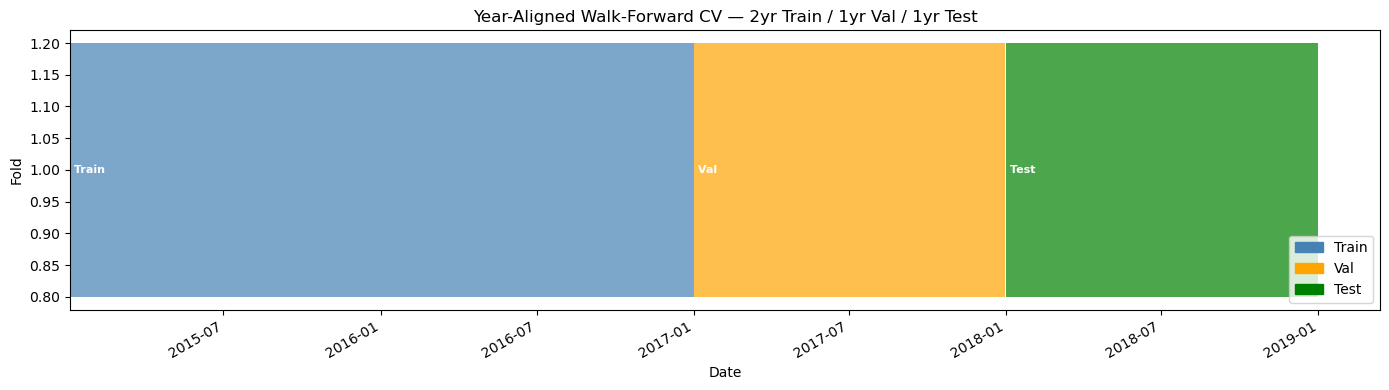

In [10]:
# Plot the fold divisions
fig, ax = plt.subplots(figsize=(14, 3 + len(folds)))
colors  = {'Train': 'steelblue', 'Val': 'orange', 'Test': 'green'}

for fold_data in folds:
    f = fold_data['fold']
    train_min = pd.Timestamp(fold_data['train_dates'].min())
    train_max = pd.Timestamp(fold_data['train_dates'].max())
    val_min   = pd.Timestamp(fold_data['val_dates'].min())
    val_max   = pd.Timestamp(fold_data['val_dates'].max())
    test_min  = pd.Timestamp(fold_data['test_dates'].min())
    test_max  = pd.Timestamp(fold_data['test_dates'].max())

    for left, right, color, label in [
        (train_min, train_max, 'steelblue', 'Train'),
        (val_min,   val_max,   'orange',    'Val'),
        (test_min,  test_max,  'green',     'Test'),
    ]:
        width = (right - left).days
        ax.barh(f, width, left=left, color=color, alpha=0.7, height=0.4)
        ax.text(left, f, f' {label}', va='center', fontsize=8,
                color='white', fontweight='bold')

ax.xaxis_date()
fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Fold')
ax.set_title('Year-Aligned Walk-Forward CV — 2yr Train / 1yr Val / 1yr Test')
patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

In [11]:
# Check scaling for fold 
fold = folds[0]

print("===== FEATURE SCALING (X) =====")
print(f"\nX_train — Min: {fold['X_train'].min():.4f}  "
      f"Max: {fold['X_train'].max():.4f}")
print(f"X_val   — Min: {fold['X_val'].min():.4f}  "
      f"Max: {fold['X_val'].max():.4f}")
print(f"X_test  — Min: {fold['X_test'].min():.4f}  "
      f"Max: {fold['X_test'].max():.4f}")

print("\n===== TARGET SCALING (y) =====")
print(f"\n{'Target':<35} {'Train Min':>10} {'Train Max':>10} "
      f"{'Val Min':>10} {'Val Max':>10} "
      f"{'Test Min':>10} {'Test Max':>10}")
print("-" * 90)

for target in ALL_TARGETS:
    y_tr = fold['y_train'][target]
    y_v  = fold['y_val'][target]
    y_te = fold['y_test'][target]

    print(f"{target:<35} "
          f"{y_tr.min():>10.4f} {y_tr.max():>10.4f} "
          f"{y_v.min():>10.4f}  {y_v.max():>10.4f} "
          f"{y_te.min():>10.4f} {y_te.max():>10.4f}")

print("\n===== PER HISTORICAL FEATURE SCALING CHECK (X) =====")
print(f"\n{'Feature':<45} {'Train Min':>10} {'Train Max':>10}")
print("-" * 68)
for i, col in enumerate(BASE_HIST_FEAT_COLS):
    print(f"{col:<45} "
          f"{fold['X_train'][:, i].min():>10.4f} "
          f"{fold['X_train'][:, i].max():>10.4f}")

===== FEATURE SCALING (X) =====

X_train — Min: -1.0000  Max: 1.0000
X_val   — Min: -1.0905  Max: 1.2092
X_test  — Min: -1.0000  Max: 1.1333

===== TARGET SCALING (y) =====

Target                               Train Min  Train Max    Val Min    Val Max   Test Min   Test Max
------------------------------------------------------------------------------------------
gen_solar                               0.0000     1.0000    -0.0016      0.9799    -0.0012     1.0000
gen_wind                                0.0000     1.0000    -0.0136      0.8912     0.0005     0.9202
total load actual                       0.0000     1.0000     0.0322      1.0310     0.0062     1.0166
price day ahead                         0.0000     1.0000     0.0000      1.2047    -0.0029     0.9889
price actual                            0.0000     1.0000     0.0284      1.1520     0.0143     0.8854

===== PER HISTORICAL FEATURE SCALING CHECK (X) =====

Feature                                        Train Min  Train

## 4. Global Model & Device Settings

In [12]:
# Initialize device based on availability
device = torch.device(
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU name     : {torch.cuda.get_device_name(0)}")
    print(f"GPU count    : {torch.cuda.device_count()}")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)     # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print(f"Random seed set: {SEED}")

# ── Sequence / horizon ──────────────────────────────────────
WINDOW_SIZE  = 168      # 1 week of hourly data (changed from 24)
HORIZON_DA   = 24       # predict next 24 hours (next day, unchanged)
HORIZON_RT   = 1        # predict next 1 hour

# ── Batch / dataloader ──────────────────────────────────────
BATCH_SIZE   = 256 if (torch.cuda.is_available() or torch.backends.mps.is_available()) else 64
NUM_WORKERS  = 4   if torch.cuda.is_available() else 0
PIN_MEMORY   = torch.cuda.is_available()

# ── Model settings ───────────────────────────────────────
INPUT_SIZE_BASE = folds[0]['X_train_base'].shape[1]
INPUT_SIZE_FC = folds[0]['Xfc_train'].shape[1]
HIDDEN_SIZE  = 256
NUM_LAYERS   = 3
DROPOUT      = 0.1


print(f"Window size            : {WINDOW_SIZE} hrs")
print(f"Day-ahead horizon      : {HORIZON_DA} hrs")
print(f"Real-time horizon      : {HORIZON_RT} hr")
print(f"Batch size             : {BATCH_SIZE}")
print(f"Num workers            : {NUM_WORKERS}")
print(f"Pin memory             : {PIN_MEMORY}")
print(f"Base Input size        : {INPUT_SIZE_BASE}")
print(f"Forecast Input size    : {INPUT_SIZE_FC}")
print(f"Hidden size            : {HIDDEN_SIZE}")
print(f"Num layers             : {NUM_LAYERS}")
print(f"Dropout                : {DROPOUT}")

Device: cuda
GPU name     : NVIDIA L40S
GPU count    : 1
Random seed set: 42
Window size            : 168 hrs
Day-ahead horizon      : 24 hrs
Real-time horizon      : 1 hr
Batch size             : 256
Num workers            : 4
Pin memory             : True
Base Input size        : 63
Forecast Input size    : 4
Hidden size            : 256
Num layers             : 3
Dropout                : 0.1


## 5. Create Dataset Classes (Day-Ahead & Real-Time)

**`DayAheadDataset`** <br>
Input: 168-hour window of training day <br>
Target: Next 24 hours 

**`RealTimeDataset`** <br>
Input: 168-hour window of training data + Model predicted generation & load features + TSO forecast generation & load features for target hour <br>
Target: Next 1 hour <br>

Model learnes to weight both cascade predictions and TSO day-ahead forecasts for next hour

In [13]:
# ---- Day-Ahead Dataset - predict next 24 hourly prices ----
# Input: last 168 hours of historical features (1 week of data)
# Target: day ahead price for each hour for the next 24 hours
class DayAheadDataset(Dataset):
    """
    Used for: gen_solar, gen_wind,
              total load actual, 
              price day ahead

    Each sample:
      x_hist     : (168, n_features)  — sliding window of historical features.
                   n_features grows at each stage as cascade columns are appended.
      y_next_day : (24,)              — next 24 hourly values of the target.
    """
    def __init__(self, X_hist, y, window_size=168, horizon=24):
        self.X    = torch.FloatTensor(X_hist)
        self.y    = torch.FloatTensor(y).squeeze(-1)
        self.win  = window_size
        self.hor  = horizon

    def __len__(self):
        return len(self.X) - self.win - self.hor + 1

    def __getitem__(self, idx):
        x_hist     = self.X[idx : idx + self.win]              # (168, n_hist)
        y_next_day = self.y[idx + self.win : idx + self.win + self.hor]  # (24,)
        
        return x_hist, y_next_day
    
# ---- Real-Time Dataset - predict next hour price ----
# Input: last 168 hours of historical features (1 week of data) + forecast features for target hour
#   forecast features include: predicted solar, wind, load + published day-ahead TSO forecast
# Target: actual price for next hour
class RealTimeDataset(Dataset):
    """
    Used for: price actual (Stage 4).

    Stream 1 — X_hist (encoder):
        Last 168 hours of the extended feature matrix.
        After predicted forecasts will contain appended cascade predictions
        for gen_solar, gen_wind, and total load actual.
        These are the model's own best estimates — not TSO actuals —
        so training matches inference conditions exactly.

    Stream 2 — X_forecast (dense head):
        Published TSO forecast features for the single target hour t:
          [forecast solar day ahead,
           forecast wind onshore day ahead,
           total load forecast,
           price day ahead]
        Comes from Xfc_train/val/test (fixed, never modified by cascade).
        TSO forecasts carry meteorological and grid
        information the upstream models do not have access to.

    Target: price actual at the next single hour t.
    """
    def __init__(self, X_hist, X_forecast, y, window_size=168):
        self.X_hist     = torch.FloatTensor(X_hist)
        self.X_forecast = torch.FloatTensor(X_forecast)
        self.y          = torch.FloatTensor(y).squeeze(-1)
        self.win        = window_size

    def __len__(self):
        return len(self.X_hist) - self.win

    def __getitem__(self, idx):
        x_hist       = self.X_hist[idx : idx + self.win]    # (168, n_hist)
        x_forecast_t = self.X_forecast[idx + self.win]      # (n_fc_features,)
        y_t          = self.y[idx + self.win]                # scalar

        return x_hist, x_forecast_t, y_t

In [14]:
# Define function for creating the dataloaders for day-ahead prediction
def create_dataloader_DA(fold_data, target, x_key='X',
                           window_size=WINDOW_SIZE, horizon=HORIZON_DA,
                           batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                           pin_memory=PIN_MEMORY):
    
    # Shared settings
    shared = dict(batch_size=batch_size, shuffle=False,
                  num_workers=num_workers, pin_memory=pin_memory,
                  persistent_workers=(num_workers > 0))
    
    # Train dataloader
    train = DataLoader(DayAheadDataset(
        fold_data[f'{x_key}_train'], fold_data['y_train'][target], window_size, horizon),
        drop_last=True, **shared
    )

    # Validation dataloader
    val = DataLoader(DayAheadDataset(
        fold_data[f'{x_key}_val'], fold_data['y_val'][target], window_size, horizon),
        drop_last=False, **shared
    )

    # Test dataloader
    test = DataLoader(DayAheadDataset(
        fold_data[f'{x_key}_test'], fold_data['y_test'][target], window_size, horizon),
        drop_last=False, **shared
    )

    return train, val, test

# Define function for creating the dataloaders for real-time prediction
def create_dataloader_RT(fold_data,
                         target=PRICE_RT_TARGET,
                         window_size=WINDOW_SIZE,       # Horizon not needed since RealTimeDataset hardcoded to predict next hour
                         batch_size=BATCH_SIZE, 
                         num_workers=NUM_WORKERS,
                         pin_memory=PIN_MEMORY):
    
    # Shared settings
    shared = dict(batch_size=batch_size, shuffle=False,
                  num_workers=num_workers, pin_memory=pin_memory,
                  persistent_workers=(num_workers > 0))
    
    # Train dataloader
    train = DataLoader(RealTimeDataset(
        fold_data['X_train'], fold_data['Xfc_train'], fold_data['y_train'][target], window_size),
        drop_last=True, **shared
    )

    # Validation dataloader
    val = DataLoader(RealTimeDataset(
        fold_data['X_val'], fold_data['Xfc_val'], fold_data['y_val'][target], window_size),
        drop_last=False, **shared
    )

    # Test dataloader
    test = DataLoader(RealTimeDataset(
        fold_data['X_test'], fold_data['Xfc_test'], fold_data['y_test'][target], window_size),
        drop_last=False, **shared
    )

    return train, val, test

# Perform shape check on base arrays
fold = folds[0]
tr, va, ts = create_dataloader_DA(fold, 'gen_solar')
x, y = next(iter(tr))
print(f"DayAheadDataset  x: {tuple(x.shape)}  y: {tuple(y.shape)}")
print(f"  → x expected   : (batch, 168, {INPUT_SIZE_BASE})")
print(f"  → y expected   : (batch, 24)")

tr_rt, va_rt, te_rt = create_dataloader_RT(fold)
xh, xfc, yt = next(iter(tr_rt))
print(f"\nRealTimeDataset  x_hist: {tuple(xh.shape)}  x_fc: {tuple(xfc.shape)}  y: {tuple(yt.shape)}")
print(f"  → x_hist expected     : (batch, 168, {INPUT_SIZE_BASE})")
print(f"  → x_fc expected       : (batch, {INPUT_SIZE_FC})  [TSO forecasts + DA price]")
print(f"  → y expected          : (batch,)")

DayAheadDataset  x: (256, 168, 63)  y: (256, 24)
  → x expected   : (batch, 168, 63)
  → y expected   : (batch, 24)

RealTimeDataset  x_hist: (256, 168, 63)  x_fc: (256, 4)  y: (256,)
  → x_hist expected     : (batch, 168, 63)
  → x_fc expected       : (batch, 4)  [TSO forecasts + DA price]
  → y expected          : (batch,)


## 6. Model Architecture

In [15]:
# CNN Encoder
class CNNEncoder(nn.Module):
    """3 layer 1D CNNs. Batch normalization after each layer to preserve timesteps.
    Accepts any input_size - can adapt to widening input feature array, X."""

    def __init__(self, input_size, cnn_channels=(64, 128, 128), kernel_sizes=(3, 5, 7)):

        super(CNNEncoder, self).__init__()
        # Conv1d operates on (batch, channels, seq_len)
        # input_size (features) = in_channels for the first layer

        self.out_channels = cnn_channels[-1]

        self.net = nn.Sequential(
            # CONV1, kernel=3, filters=64
            nn.Conv1d(in_channels=input_size, out_channels=cnn_channels[0], 
                      kernel_size=kernel_sizes[0], stride=1, 
                      padding=(kernel_sizes[0] - 1) // 2),       # Handles both odd and even kernel sizes to preserve sequence length
            nn.BatchNorm1d(cnn_channels[0]),
            nn.ReLU(),

            # CONV2, kernel=5, filters=128
            # Increase padding in order to preserve sequence length between convolution layers
            nn.Conv1d(in_channels=cnn_channels[0], out_channels=cnn_channels[1], 
                      kernel_size=kernel_sizes[1], stride=1, 
                      padding=(kernel_sizes[1] - 1) // 2),
            nn.BatchNorm1d(cnn_channels[1]),
            nn.ReLU(),

            # CONV3, kernel=7, filters=128
            # Increase padding in order to preserve sequence length between convolution layers
            nn.Conv1d(in_channels=cnn_channels[1], out_channels=cnn_channels[2], 
                      kernel_size=kernel_sizes[2], stride=1, 
                      padding=(kernel_sizes[2] - 1) // 2),
            nn.BatchNorm1d(cnn_channels[2]),
            nn.ReLU(),
        )

    def forward(self, x):
        # x in:  (batch, seq_len, input_size)  — standard time-series format
        x = x.permute(0, 2, 1)      # → (batch, input_size,  seq_len) for Conv1d
        x = self.net(x)        # → (batch, 128, seq_len)
        x = x.permute(0, 2, 1)      # → (batch, seq_len, 128)    for GRU
        return x

# Attention layer
class AttentionLayer(nn.Module):
    """Attention over LSTM hidden states
    Hidden size dimension must be equal to GRU output dimension"""

    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        # learns importance score for each timestep
        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        # gru_output: (batch, window, hidden_size)

        # compute score for each timestep
        scores = self.attention(lstm_output).squeeze(-1)   # (batch, window)

        # convert scores to probabilities
        weights = F.softmax(scores, dim=1)    # (batch, window)

        # weighted sum of all hidden states
        weights  = weights.unsqueeze(-1)       # (batch, window, 1)
        context  = torch.sum(lstm_output * weights, dim=1)      # (batch, hidden_size)

        return context, weights.squeeze(-1)
    
# Shared Encoder for all predictions (generation, load, price)
class SharedEncoder(nn.Module):
    """
    CNN -> Bidirectional LSTM -> Attention
    Output: context (B, hidden_size*2), attn_weights (B, 168).
    Shared across all four pipeline stages.
    input_size is passed at construction time and reflects the current
    width of X (base + however many cascade columns have been appended).
    """
    def __init__(self, input_size, cnn_channels=(64, 128, 128), kernel_sizes=(3, 5, 7),
                 hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn = CNNEncoder(input_size, cnn_channels, kernel_sizes)
        self.lstm = nn.LSTM(
            input_size=cnn_channels[-1],
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=True,
        )
        self.drop  = nn.Dropout(dropout)
        self.attn  = AttentionLayer(hidden_size * 2)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(self.cnn(x))
        return self.attn(self.drop(out))
    
# Day Ahead Prediction Decoder
class DayAheadDecoder(nn.Module):
    """
    Autoregressive LSTM decoder — prediction for hour 1 is fed as input for hour 2
    so on and so forth. Allows decoder to capture intra-day price signals and relationships
    """
    def __init__(self, hidden_size, output_steps=24):
        super().__init__()
        self.steps = output_steps
        self.lstm   = nn.LSTM(1, hidden_size, num_layers=1, batch_first=True)
        self.fc    = nn.Linear(hidden_size, 1)

    def forward(self, context):
        h   = context.unsqueeze(0)
        c   = torch.zeros_like(h)
        dec = torch.zeros(context.size(0), 1, 1, device=context.device)
        out = []
        for _ in range(self.steps):

            # LSTM takes previous prediction, hidden state, cell state
            h_out, (h,c) = self.lstm(dec, (h, c))

            # Predict hour t
            p = self.fc(h_out)     # (B,1,1)
            out.append(p.squeeze(-1))

            # Feed prediction as input in subsequent time step
            dec = p
        return torch.cat(out, dim=1)   # (B, 24)

In [16]:
# Transformer Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)
    
# Transformer Encoder w/ Self-Attention
class SharedTransformerEncoder(nn.Module):
    """
    Linear projection → Positional Encoding → Transformer Encoder.

    Replaces SharedEncoder (CNN → BiLSTM → Attention) as an alternative
    backbone. The interface is identical: takes x_hist and returns
    (context, attn_weights) so DayAheadModel and PriceRealTimeModel
    work without modification.

    context     : (B, d_model) — mean-pooled across the 168 timesteps.
                  Mean pooling uses the full sequence rather than just
                  the last timestep, which tends to work better for
                  day-ahead forecasting where the full week of history
                  matters rather than only the most recent hour.

    attn_weights: (B, 168) — attention weights from the final encoder
                  layer's first head, extracted for interpretability.
                  These show which timesteps the model weighted most
                  heavily when forming the context vector.
    """
    def __init__(self, input_size, d_model=128, nhead=8,
                 num_encoder_layers=3, dim_feedforward=256,
                 dropout=0.1):
        super().__init__()

        assert d_model % nhead == 0, (
            f"d_model ({d_model}) must be divisible by nhead ({nhead})")

        self.input_proj   = nn.Linear(input_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_encoder_layers,
        )
        self.d_model = d_model

    def forward(self, x):
        # x: (B, 168, input_size)
        x = self.input_proj(x)        # (B, 168, d_model)
        x = self.pos_encoding(x)      # (B, 168, d_model)
        x = self.transformer(x)       # (B, 168, d_model)

        # ── Context vector via mean pooling ───────────────────────────────────
        # Mean pool across the 168 timesteps so all of history contributes.
        # Alternative: x[:, -1, :] uses only the last timestep — simpler but
        # discards earlier history. Switch to last-timestep if mean pooling
        # underperforms on val.
        context = x.mean(dim=1)       # (B, d_model)

        # ── Attention weights for interpretability ────────────────────────────
        # Re-run a single attention pass on the encoder output to get
        # per-timestep importance weights. Uses mean across heads for
        # a single (B, 168) summary weight vector.
        with torch.no_grad():
            # Compute scaled dot-product attention scores from final layer output
            # Shape: (B, 168) — one weight per timestep
            scores      = (x * x.mean(dim=1, keepdim=True)).sum(dim=-1)
            attn_weights = torch.softmax(scores, dim=1)   # (B, 168)

        return context, attn_weights

In [17]:
# Day-Ahead Prediction Full Model (CNN+BiLSTM)
class DayAheadModel(nn.Module):
    """
    Used for: gen_solar, gen_wind, total load actual, price day ahead.
    input_size is read from fold_data['X_train'].shape[1] at each stage.
    """
    def __init__(self, input_size, cnn_channels=(64, 128, 128), kernel_sizes=(3, 5, 7),
                 hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = SharedEncoder(input_size, cnn_channels, kernel_sizes, hidden_size, num_layers, dropout)
        self.decoder = DayAheadDecoder(hidden_size * 2, output_steps=24)

    def forward(self, x_hist):
        context, attn = self.encoder(x_hist)
        return self.decoder(context), attn


# Real-Time Prediction Full Model (CNN+BiLSTM)
class RealTimeModel(nn.Module):
    """
    Predicts price actual for the next single hour.

    Stream 1 — SharedEncoder over x_hist (168, input_size_extended):
        input_size_extended = base features
                            + gen_solar cascade prediction    (1 col)
                            + gen_wind cascade prediction     (1 col)
                            + total load cascade prediction   (1 col)
        The encoder produces a context vector of shape (B, hidden_size*2).

    Stream 2 — Dense head receives context concatenated with x_forecast:
        x_forecast = [forecast_solar_day_ahead,        (TSO)
                       forecast_wind_onshore_day_ahead, (TSO)
                       total_load_forecast,             (TSO)
                       price_day_ahead]                 (settled market)
        These complement the cascade predictions with information
        the upstream models do not have (meteorological models, grid data).
        The model learns to weight Stream 1 and Stream 2 jointly.
    """
    def __init__(self, input_size, n_forecast_features,
                 cnn_channels=(64, 128, 128), kernel_sizes=(3, 5, 7),
                 hidden_size=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.encoder = SharedEncoder(input_size, cnn_channels, kernel_sizes, hidden_size, num_layers, dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2 + n_forecast_features, 256),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_hist, x_forecast):
        context, attn = self.encoder(x_hist)
        return self.head(torch.cat([context, x_forecast], dim=-1)), attn

In [18]:
# ── Transformer Day-Ahead Model ───────────────────────────────────────────────
class TransformerDayAheadModel(nn.Module):
    """
    Transformer-based day-ahead model.
    Replaces DayAheadModel (CNN + BiLSTM + autoregressive decoder).

    The output head projects directly from context to all 24 hours in
    one shot rather than autoregressively. This is appropriate for the
    transformer because the full sequence context is already captured
    by the encoder — the autoregressive decoder was needed in the LSTM
    version to carry forward intra-day dependencies that the LSTM encoder
    could not propagate across the horizon. The transformer's self-attention
    already captures those relationships within the 168-hour input window.

    Input  : x_hist (B, 168, input_size)
    Output : pred   (B, 24), attn_weights (B, 168)
    """
    def __init__(self, input_size, d_model=128, nhead=8,
                 num_encoder_layers=3, dim_feedforward=256,
                 dropout=0.1):
        super().__init__()
        self.encoder = SharedTransformerEncoder(
            input_size=input_size,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 24),
        )

    def forward(self, x_hist):
        context, attn = self.encoder(x_hist)      # (B, d_model), (B, 168)
        pred          = self.output_head(context)  # (B, 24)
        return pred, attn

# ── Transformer Real-Time Model ───────────────────────────────────────────────
class TransformerRealTimeModel(nn.Module):
    """
    Transformer-based real-time price model.
    Replaces PriceRealTimeModel (CNN + BiLSTM + dense head).

    Stream 1 (encoder) : x_hist     (B, 168, input_size_extended)
                         By Stage 4, input_size_extended includes
                         cascade predictions for gen_solar, gen_wind,
                         and total load actual appended to base features.
    Stream 2 (head)    : x_forecast (B, n_forecast_features)
                         Published TSO forecasts + settled day-ahead price.

    Input  : x_hist (B, 168, input_size), x_forecast (B, n_forecast_features)
    Output : pred   (B, 1),               attn_weights (B, 168)
    """
    def __init__(self, input_size, n_forecast_features,
                 d_model=128, nhead=8,
                 num_encoder_layers=3, dim_feedforward=256,
                 dropout=0.1):
        super().__init__()
        self.encoder = SharedTransformerEncoder(
            input_size=input_size,
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        # Dense head: context (d_model) concatenated with Stream 2 forecasts
        self.head = nn.Sequential(
            nn.Linear(d_model + n_forecast_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x_hist, x_forecast):
        context, attn = self.encoder(x_hist)
        combined      = torch.cat([context, x_forecast], dim=-1)
        pred          = self.head(combined)        # (B, 1)
        return pred, attn



In [19]:
# Define a function to build the Day Ahead Price prediction model based on indicated architecture
def build_dayahead_model(input_size, cfg):
    """Instantiate the correct day-ahead model based on cfg['arch']."""
    if cfg['arch'] == 'transformer':
        return TransformerDayAheadModel(
            input_size=input_size,
            d_model=cfg['d_model'],
            nhead=cfg['nhead'],
            num_encoder_layers=cfg['num_enc_layers'],
            dim_feedforward=cfg['dim_feedforward'],
            dropout=cfg['dropout'],
        )
    else:
        return DayAheadModel(
            input_size=input_size,
            cnn_channels=cfg['cnn_channels'],
            kernel_sizes=cfg['kernel_sizes'],
            hidden_size=cfg['hidden_size'],
            num_layers=NUM_LAYERS,
            dropout=cfg['dropout'],
        )

# Define a function to build the Real Time Price prediction model based on indicated architecture
def build_realtime_model(input_size, n_forecast_features, cfg):
    """Instantiate the correct real-time model based on cfg['arch']."""
    if cfg['arch'] == 'transformer':
        return TransformerRealTimeModel(
            input_size=input_size,
            n_forecast_features=n_forecast_features,
            d_model=cfg['d_model'],
            nhead=cfg['nhead'],
            num_encoder_layers=cfg['num_enc_layers'],
            dim_feedforward=cfg['dim_feedforward'],
            dropout=cfg['dropout'],
        )
    else:
        return RealTimeModel(
            input_size=input_size,
            n_forecast_features=n_forecast_features,
            cnn_channels=cfg['cnn_channels'],
            kernel_sizes=cfg['kernel_sizes'],
            hidden_size=cfg['hidden_size'],
            num_layers=NUM_LAYERS,
            dropout=cfg['dropout'],
        )

In [20]:
# ── Sanity check on base input size before any cascade ────────────────────────
_cfg = {'hidden_size': 256, 
        'num_layers': 2, 
        'dropout': 0.1}
fd   = folds[0]

clstm_da = DayAheadModel(input_size=INPUT_SIZE_BASE, **_cfg)
clstm_rt = RealTimeModel(input_size=INPUT_SIZE_BASE,
                          n_forecast_features=INPUT_SIZE_FC, **_cfg)

def _count(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
print(f"CNN+LSTM DayAheadModel params: {_count(clstm_da):,}")
print(f"CNN+LSTM RealTimeModel params: {_count(clstm_rt):,}")

with torch.no_grad():
    _xh  = torch.zeros(2, 168, INPUT_SIZE_BASE)
    _xfc = torch.zeros(2, INPUT_SIZE_FC)
    _p_da, _a_da = clstm_da(_xh)
    _p_rt, _a_rt = clstm_rt(_xh, _xfc)

print(f"\nDayAhead  output: {tuple(_p_da.shape)}   (expect (2, 24))")
print(f"Attention output: {tuple(_a_da.shape)}  (expect (2, 168))")
print(f"RealTime  output: {tuple(_p_rt.shape)}   (expect (2, 1))")
print(f"\nNote: input_size will grow by 1 per cascade stage.")
print(f"  After Stage 1a: input_size = {INPUT_SIZE_BASE + 1}")
print(f"  After Stage 1b: input_size = {INPUT_SIZE_BASE + 2}")
print(f"  After Stage 2 : input_size = {INPUT_SIZE_BASE + 3}  (used by Stages 3 & 4)")
del clstm_da, clstm_rt

CNN+LSTM DayAheadModel params: 3,591,938
CNN+LSTM RealTimeModel params: 2,702,082

DayAhead  output: (2, 24)   (expect (2, 24))
Attention output: (2, 168)  (expect (2, 168))
RealTime  output: (2, 1)   (expect (2, 1))

Note: input_size will grow by 1 per cascade stage.
  After Stage 1a: input_size = 64
  After Stage 1b: input_size = 65
  After Stage 2 : input_size = 66  (used by Stages 3 & 4)


In [21]:
# Instantiate model
INPUT_SIZE  = folds[0]['X_train'].shape[1]
HIDDEN_SIZE = 256
NUM_LAYERS  = 2
DROPOUT     = 0.3

model = DayAheadModel(
    input_size=INPUT_SIZE,
    cnn_channels=(64, 128, 128),
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

print(model)
print(f"\nInput size  : {INPUT_SIZE}")
print(f"Hidden size : {HIDDEN_SIZE}")
print(f"Num layers  : {NUM_LAYERS}")
print(f"Bidirectional — FC input: {HIDDEN_SIZE * 2}")

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() 
                   if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")


DayAheadModel(
  (encoder): SharedEncoder(
    (cnn): CNNEncoder(
      (net): Sequential(
        (0): Conv1d(63, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
        (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
        (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): ReLU()
      )
    )
    (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (drop): Dropout(p=0.3, inplace=False)
    (attn): AttentionLayer(
      (attention): Linear(in_features=512, out_features=1, bias=True)
    )
  )
  (decoder): DayAheadDecoder(
    (lstm): LSTM(1, 512, batch_first=True)
    (fc): Linear(

## 7. Training & Evaluation Functions

In [22]:
class CustomLoss(nn.Module):
    def __init__(self, alpha=0.1, beta=0.01):
        super(CustomLoss, self).__init__()
        self.alpha = alpha
        self.beta  = beta

    def forward(self, y_pred, y_true):
        # Ensure same shape
        y_pred = y_pred.squeeze()
        y_true = y_true.squeeze()

        # ── MAE ─────────────────────────────────────────
        mae = torch.mean(torch.abs(y_true - y_pred))

        # ── JSD ─────────────────────────────────────────
        y_true_soft = torch.softmax(y_true, dim=0)
        y_pred_soft = torch.softmax(y_pred, dim=0)
        m           = 0.5 * (y_true_soft + y_pred_soft)
        kl1         = torch.sum(
            y_true_soft * torch.log(y_true_soft / (m + 1e-8) + 1e-8))
        kl2         = torch.sum(
            y_pred_soft * torch.log(y_pred_soft / (m + 1e-8) + 1e-8))
        jsd         = 0.5 * (kl1 + kl2)

        # ── Smoothness ───────────────────────────────────
        smoothness  = torch.mean((y_pred[1:] - y_pred[:-1]) ** 2)

        return mae + self.alpha * jsd + self.beta * smoothness

In [23]:
# Training loop function
def train_model(model, train_loader, val_loader,
                model_type='dayahead',
                num_epochs=50, lr=0.001,
                loss_fn='mae', alpha=0.1, beta=0.01):
    
    """
    Generic training loop for all four pipeline stages.

    model_type 'dayahead' : batch = (X_hist, y_24hr)
               'realtime' : batch = (X_hist, X_forecast, y_scalar)
                            X_hist contains cascade columns (Stream 1)
                            X_forecast contains TSO forecasts (Stream 2)
    """
    # Move model to device
    model = model.to(device)

    # Define criterion for loss function
    if loss_fn == 'mae':
        criterion = nn.L1Loss()
        print(f"Loss: MAE")
    elif loss_fn == 'mse':
        criterion = nn.MSELoss()
        print(f"Loss: MSE")
    elif loss_fn == 'custom':
        criterion = CustomLoss(alpha=alpha, beta=beta)
        print(f"Loss: Custom α={alpha} β={beta}")
    else:
        raise ValueError("loss_fn must be 'mae', 'mse' or 'custom'")

    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Define the learning rate scheduler for decreasing learning rate as necessary
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=5,
        factor=0.5
    )

    # Track model training history, losses, and weights
    best_val_loss = float('inf')
    best_weights  = copy.deepcopy(model.state_dict())
    history       = {
        'train_loss': [],
        'val_loss'  : [],
        'lr'        : []
    }

    # Record total training start time
    train_start = time.time()

    for epoch in range(num_epochs):

        # Record epoch start time
        epoch_start = time.time()

        # ══════════════════════════════════════════════
        # TRAINING
        # ══════════════════════════════════════════════
        # Set model in training mode
        model.train()

        # Initalize empty list for storing training loss
        train_losses = []

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1:>3}/{num_epochs} [Train]",
            leave=False
        )

        # Train model in batches
        for batch in train_bar:
            if model_type == 'dayahead':
                # Unpack and move data to device
                X_batch, y_batch = batch
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                # Obtain the prediction
                pred, _ = model(X_batch)

                # Compute the loss
                loss = criterion(pred, y_batch)
            else:
                # Move data to device
                X_batch, X_forecast, y_batch = batch
                X_batch, X_forecast, y_batch = X_batch.to(device), X_forecast.to(device), y_batch.to(device)

                # Add dimension to target
                y_batch = y_batch.unsqueeze(-1)

                # Obtain the prediction
                pred, _ = model(X_batch, X_forecast)

                # Compute the loss
                loss = criterion(pred, y_batch)

            # skip NaN values
            if torch.isnan(loss) or torch.isinf(loss):
                print(f" NaN/Inf — skipping batch")
                continue

            # Backward pass
            optimizer.zero_grad()
            loss.backward()

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0)

            # Step the optimizer
            optimizer.step()
            train_losses.append(loss.item())

            train_bar.set_postfix({
                # '1hr' : f"{loss_1hr.item():.4f}",
                # '24hr': f"{loss_24hr.item():.4f}",
                'avg' : f"{np.mean(train_losses):.4f}"
            })

        avg_train_loss = float(np.mean(train_losses)) if train_losses else float('nan')

        # ══════════════════════════════════════════════
        # VALIDATION
        # ══════════════════════════════════════════════
        # Set model in evaluation mode
        model.eval()

        # Initalize empty list for storing validation loss
        val_losses = []

        val_bar = tqdm(
            val_loader,
            desc=f"Epoch {epoch+1:>3}/{num_epochs} [Val]  ",
            leave=False
        )

        with torch.no_grad():
            for batch in val_bar:
                if model_type == 'dayahead':
                    # Unpack and move data to device
                    X_batch, y_batch = batch
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                    # Obtain the prediction
                    pred, _ = model(X_batch)

                    # Compute the loss
                    loss = criterion(pred, y_batch)
                else:
                    # Unpack and move data to device
                    X_batch, X_forecast, y_batch = batch
                    X_batch, X_forecast, y_batch = X_batch.to(device), X_forecast.to(device), y_batch.to(device)

                    # Add dimension to target
                    y_batch = y_batch.unsqueeze(-1)

                    # Obtain the prediction
                    pred, _ = model(X_batch, X_forecast)

                    # Compute the loss
                    loss = criterion(pred, y_batch)

                if torch.isnan(loss) or \
                   torch.isinf(loss):
                    continue

                val_losses.append(loss.item())

                val_bar.set_postfix({
                    # '1hr' : f"{loss_1hr.item():.4f}",
                    # '24hr': f"{loss_24hr.item():.4f}",
                    'avg' : f"{np.mean(val_losses):.4f}"
                })

        avg_val_loss = float(np.mean(val_losses)) if val_losses else float('nan')

        # ── Save best model ───────────────────────────
        if not np.isnan(avg_val_loss) and avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            print(f"  ✅ Epoch {epoch+1:>3} — "
                  f"best model saved "
                  f"val={best_val_loss:.4f}")

        # ── Scheduler step ────────────────────────────
        if not np.isnan(avg_val_loss):
            scheduler.step(avg_val_loss)

        # ── Store history ─────────────────────────────
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # ── Epoch summary ─────────────────────────────
        epoch_mins, epoch_secs = divmod(int(time.time() - epoch_start), 60)
        print(f"Epoch {epoch+1:>3}/{num_epochs} | "
              f"Train: {avg_train_loss:.4f} | "
              f"Val: {avg_val_loss:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
              f"Time: {epoch_mins}m {epoch_secs:02d}s")

    # ── Load best weights ─────────────────────────────
    model.load_state_dict(best_weights)
    print(f"\nTraining complete — "
          f"best val loss: {best_val_loss:.4f}")
    
    # ── Total training duration ───────────────────────
    total_mins, total_secs = divmod(int(time.time() - train_start), 60)
    print(f"\nTraining complete — "
          f"best val loss: {best_val_loss:.4f} | "
          f"Total time: {total_mins}m {total_secs:02d}s")
    
    return model, history

In [24]:
def evaluate_model(model, test_loader, target_scaler, model_type='dayahead', split_name='val'):
    """
    Evaluate on any loader split.  Returns inverse-transformed arrays
    and a metrics dict.

    Call with val loader during HP tuning.
    Call with test loader once only after HPs are locked.
    """
    # Set model in evaluation mode
    model.eval()

    # Initalize lists for storing all predictions and actual values
    all_preds, all_actuals = [], []
    
    test_bar = tqdm(
        test_loader,
        desc="Testing",
        leave=True
    )

    with torch.no_grad():
        for batch in test_bar:
            if model_type == 'dayahead':
                # Unpack batch and move to device
                X_batch, y_batch = batch
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                # Obtain the prediction
                pred, _ = model(X_batch)
            else:
                # Unpack batch and move data to device
                X_batch, X_forecast, y_batch = batch
                X_batch, X_forecast, y_batch = X_batch.to(device), X_forecast.to(device), y_batch.to(device)

                # Add dimension to target
                y_batch = y_batch.unsqueeze(-1)

                # Obtain the prediction
                pred, _ = model(X_batch, X_forecast)

            # Append all predictions and actuals
            all_preds.append(pred.cpu().numpy())
            all_actuals.append(y_batch.cpu().numpy())
    
    # Concatenate all predictions and actuals
    preds = np.concatenate(all_preds, axis=0)
    actuals = np.concatenate(all_actuals, axis=0)

    # Inverse transform on the predictions and actuals from scaling
    if model_type == 'dayahead':
        n = preds.shape[0]
        preds_orig = target_scaler.inverse_transform(preds.reshape(-1,1)).reshape(n,24)
        actuals_orig  = target_scaler.inverse_transform(actuals.reshape(-1,1)).reshape(n,24)
    else:
        preds_orig = target_scaler.inverse_transform(preds.reshape(-1,1))
        actuals_orig  = target_scaler.inverse_transform(actuals.reshape(-1,1))

    # Compute evaluation metrics
    mae     = float(np.mean(np.abs(actuals_orig - preds_orig)))
    rmse    = float(np.sqrt(np.mean((actuals_orig - preds_orig)**2)))
    rng     = float(actuals_orig.max() - actuals_orig.min())
    # mae_pct = (mae / rng * 100) if rng > 0 else float('nan')
    mask = actuals_orig != 0
    mape = float(np.mean(np.abs(actuals_orig[mask] - preds_orig[mask]) / 
                     actuals_orig[mask]) * 100) if mask.any() else float('nan')

    # sMAPE — robust for solar/wind (zeros) and prices (negatives)
    denom = (np.abs(actuals_orig) + np.abs(preds_orig)) / 2
    mask  = denom != 0
    smape = float(np.mean(np.abs(actuals_orig[mask] - preds_orig[mask]) /
                      denom[mask]) * 100) if mask.any() else float('nan')

    # Print the results
    print(f"  [{split_name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE%={mape:.2f}%  sMAPE={smape:.2f}%)

    return preds_orig, actuals_orig, {'mae': mae, 'rmse': rmse,
                                    'mape': mape, 'smape': smape, 'range': rng}

## 8. Cascade Prediction Helper Function

`append_cascade_to_fold()` runs a trained Stage 1/2 model over every split,
extracts its single-step-ahead prediction at each row, scales it to [0,1],
and appends it as a new column to `fold_data['X_train/val/test']`.

After this call the next stage's `make_loaders_dayahead()` or
`make_loaders_realtime()` will automatically produce batches with the
wider X matrix — both `DayAheadDataset` and `RealTimeDataset` adapt to
the new width without any modification.

In [25]:
def _generate_single_step_preds(model, X_split, y_split,
                                  window_size=WINDOW_SIZE, horizon=HORIZON_DA,
                                  batch_size=BATCH_SIZE):
    """
    Slide the model over X_split and collect one predicted value per row.

    For each window starting at index i the model produces a 24-hr forecast.
    We keep only the FIRST predicted hour (t+1) as the single-step estimate
    for row i+window_size.  The leading window_size rows are back-filled
    with the first available prediction.

    Returns: np.ndarray of shape (len(X_split),) — one value per row,
             in the same scaled space as the model outputs ([0, 1]).
    """
    dataset = DayAheadDataset(X_split, y_split, window_size, horizon)
    loader  = DataLoader(dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0)
    model.eval()
    step_preds = []

    with torch.no_grad():
        for xb, _ in loader:
            pred, _ = model(xb.to(device))   # (batch, 24)
            step_preds.append(pred[:, 0].cpu().numpy())  # keep hour-1 only

    step_preds = np.concatenate(step_preds)  # (N - window - horizon + 1,)

    # Pad front so output length == len(X_split)
    pad     = np.full(window_size + horizon - 1, step_preds[0])
    aligned = np.concatenate([pad, step_preds])[:len(X_split)]
    return aligned.astype(np.float32)


def append_cascade_to_fold(fold_data, target, trained_model,
                             window_size=WINDOW_SIZE):
    """
    Append upstream model predictions as a new feature column to
    fold_data['X_train'], fold_data['X_val'], and fold_data['X_test'].

    The appended values are the model's own [0,1]-scaled predictions,
    produced independently for each split using the split's own X array.
    This means:
      - Train split: model sees training-distribution inputs
      - Val split  : model sees val-distribution inputs (no leakage)
      - Test split : model sees test-distribution inputs (no leakage)

    After this call the downstream stage automatically receives the
    extended X when make_loaders_dayahead / make_loaders_realtime is called.
    """
    for split in ('train', 'val', 'test'):
        X_split = fold_data[f'X_{split}']
        y_split = fold_data[f'y_{split}'][target]

        preds = _generate_single_step_preds(
            trained_model, X_split, y_split, window_size=window_size)

        fold_data[f'X_{split}'] = np.hstack(
            [X_split, preds.reshape(-1, 1)])

    old_w = fold_data['X_train'].shape[1] - 1
    new_w = fold_data['X_train'].shape[1]
    fold_data.setdefault('cascade_preds', {})[target] = True
    print(f"  Cascade appended '{target}': X width {old_w} → {new_w}")


def reset_cascade(fold_data):
    """Reset working X arrays to base before each HP config."""
    fold_data['X_train']      = fold_data['X_train_base'].copy()
    fold_data['X_val']        = fold_data['X_val_base'].copy()
    fold_data['X_test']       = fold_data['X_test_base'].copy()
    fold_data['cascade_preds'] = {}
    print(f"Cascade reset — X width back to {fold_data['X_train'].shape[1]}")

## 9. Visualization Helper Functions

In [26]:
def plot_results(preds, actuals, history, stage_label, target_name, split_name):
    is_da  = (preds.ndim == 2 and preds.shape[1] == 24)
    nrows  = 3 if is_da else 2
    fig    = plt.figure(figsize=(16, 5 * (nrows + 1)))
    fig.suptitle(f'{stage_label} — {target_name}  [{split_name}]',
                 fontsize=14, fontweight='bold')
    gs = gridspec.GridSpec(nrows + 1, 2, figure=fig, hspace=0.5, wspace=0.3)

    fp, fa = preds.flatten(), actuals.flatten()

    ax = fig.add_subplot(gs[0, :])
    ax.plot(fa, label='Actual',    color='steelblue', alpha=0.7, lw=0.8)
    ax.plot(fp, label='Predicted', color='orange',    alpha=0.7, lw=0.8)
    ax.set_title(f'Full {split_name} Period'); ax.set_xlabel('Hour index')
    ax.set_ylabel('Value'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 0])
    ax.plot(fa[:168], color='steelblue', label='Actual',    alpha=0.7)
    ax.plot(fp[:168], color='orange',    label='Predicted', alpha=0.7)
    ax.set_title('First 7 Days'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[1, 1])
    ax.scatter(fa, fp, alpha=0.2, color='steelblue', s=4)
    lo, hi = min(fa.min(), fp.min()), max(fa.max(), fp.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Perfect')
    ax.set_title('Scatter'); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(); ax.grid(True, alpha=0.3)

    if is_da:
        for j, (si, st) in enumerate([(0,'Sample Day 1'),(100,'Sample Day 100')]):
            si = min(si, len(preds)-1)
            ax = fig.add_subplot(gs[2, j])
            ax.plot(range(24), actuals[si], color='steelblue', marker='o',
                    markersize=4, label='Actual')
            ax.plot(range(24), preds[si],   color='orange',    marker='x',
                    markersize=4, label='Predicted')
            ax.set_title(f'24hr Profile — {st}')
            ax.set_xlabel('Hour'); ax.legend(); ax.grid(True, alpha=0.3)

    ax = fig.add_subplot(gs[nrows, :])
    ep = range(1, len(history['train_loss'])+1)
    ax.plot(ep, history['train_loss'], color='steelblue', lw=1.5, label='Train')
    ax.plot(ep, history['val_loss'],   color='orange',    lw=1.5, label='Val')
    ax.set_title('Loss Curves'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

In [27]:
def plot_loss_curves(history, title):
    """
    Plot train and validation loss curves from a history dict.
    Marks the best epoch (lowest val loss) with a vertical line.
    """
    train_loss = history['train_loss']
    val_loss   = history['val_loss']
    epochs     = range(1, len(train_loss) + 1)
    best_epoch = int(np.argmin(val_loss)) + 1

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs, train_loss, color='steelblue', lw=1.5, label='Train')
    ax.plot(epochs, val_loss,   color='orange',    lw=1.5, label='Validation')
    ax.axvline(x=best_epoch, color='red', linestyle='--', lw=1.2,
               label=f'Best epoch ({best_epoch})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [28]:
def get_cascade_preds(fold_data, target, trained_model, window_size=168, x_key='X'):
    """Returns a dict of {split: preds_array} without modifying fold_data."""
    result = {}
    for split in ('train', 'val', 'test'):
        X_split = fold_data[f'{x_key}_{split}']
        y_split = fold_data[f'y_{split}'][target]
        result[split] = _generate_single_step_preds(
            trained_model, X_split, y_split, window_size=window_size)
    return result

## 10. Single Model Configuration Train/Val/Test

Fold 1: train=[np.int32(2015), np.int32(2016)]  val=[np.int32(2017)]  test=[np.int32(2018)] (held out)
Config: {'arch': 'cnnlstm', 'hidden_size': 256, 'cnn_channels': (64, 128, 256), 'kernel_sizes': (3, 8, 12), 'd_model': 64, 'nhead': 4, 'num_enc_layers': 2, 'dim_feedforward': 256, 'dropout': 0.1, 'lr': 0.001, 'loss_fn': 'mse'}

Cascade reset — X width back to 63

STAGE 1a — gen_solar  (X width=58)
Solar Generation Forecast Day Ahead Model params: 4156610
Loss: MSE


  ✅ Epoch   1 — best model saved val=0.1021
Epoch   1/50 | Train: 0.0840 | Val: 0.1021 | LR: 0.001000 | Time: 0m 05s


Epoch   2/50 | Train: 0.0809 | Val: 0.1040 | LR: 0.001000 | Time: 0m 04s


  ✅ Epoch   3 — best model saved val=0.0550
Epoch   3/50 | Train: 0.0361 | Val: 0.0550 | LR: 0.001000 | Time: 0m 04s


  ✅ Epoch   4 — best model saved val=0.0526
Epoch   4/50 | Train: 0.0306 | Val: 0.0526 | LR: 0.001000 | Time: 0m 04s


...

Epoch  48/50 | Train: 0.0264 | Val: 0.0359 | LR: 0.000063 | Time: 0m 04s


Epoch  49/50 | Train: 0.0263 | Val: 0.0368 | LR: 0.000031 | Time: 0m 04s


Epoch  50/50 | Train: 0.0259 | Val: 0.0379 | LR: 0.000031 | Time: 0m 04s

Training complete — best val loss: 0.0347

Training complete — best val loss: 0.0347 | Total time: 4m 05s


Testing: 100%|██████████| 34/34 [00:00<00:00, 113.05it/s]


  [val]  MAE=745.5577  RMSE=1072.9911  MAPE%=1249856128.00%


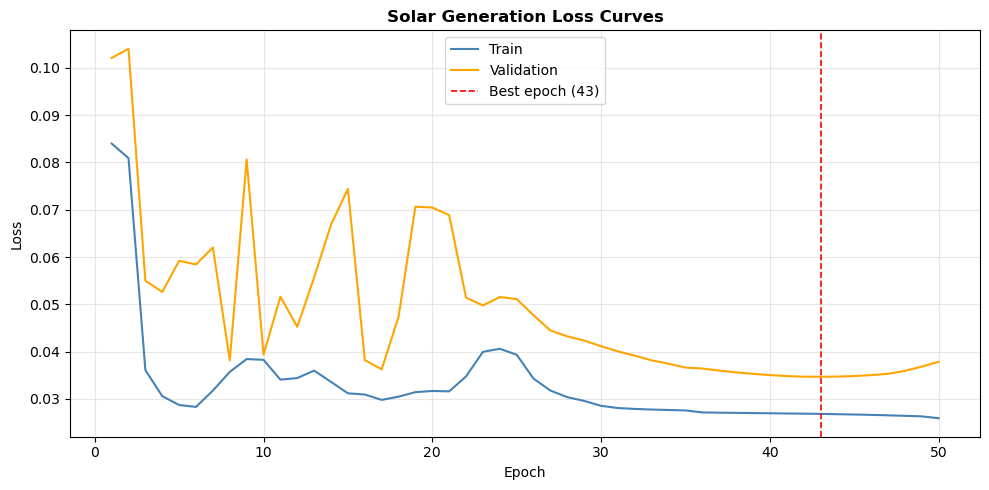


STAGE 1b — gen_wind  (X width=58)
Wind Generation Forecast Day Ahead Model params: 4156610
Loss: MSE


  ✅ Epoch   1 — best model saved val=0.0325
Epoch   1/50 | Train: 0.0447 | Val: 0.0325 | LR: 0.001000 | Time: 0m 04s


Epoch   2/50 | Train: 0.0371 | Val: 0.0338 | LR: 0.001000 | Time: 0m 04s


Epoch   3/50 | Train: 0.0390 | Val: 0.0341 | LR: 0.001000 | Time: 0m 04s


Epoch   4/50 | Train: 0.0393 | Val: 0.0344 | LR: 0.001000 | Time: 0m 04s


...

Epoch  48/50 | Train: 0.0181 | Val: 0.1042 | LR: 0.000008 | Time: 0m 04s


Epoch  49/50 | Train: 0.0181 | Val: 0.1044 | LR: 0.000004 | Time: 0m 04s


Epoch  50/50 | Train: 0.0181 | Val: 0.1043 | LR: 0.000004 | Time: 0m 05s

Training complete — best val loss: 0.0325

Training complete — best val loss: 0.0325 | Total time: 4m 05s


Testing: 100%|██████████| 34/34 [00:00<00:00, 102.11it/s]


  [val]  MAE=2404.6943  RMSE=3017.5129  MAPE%=-26128140.00%


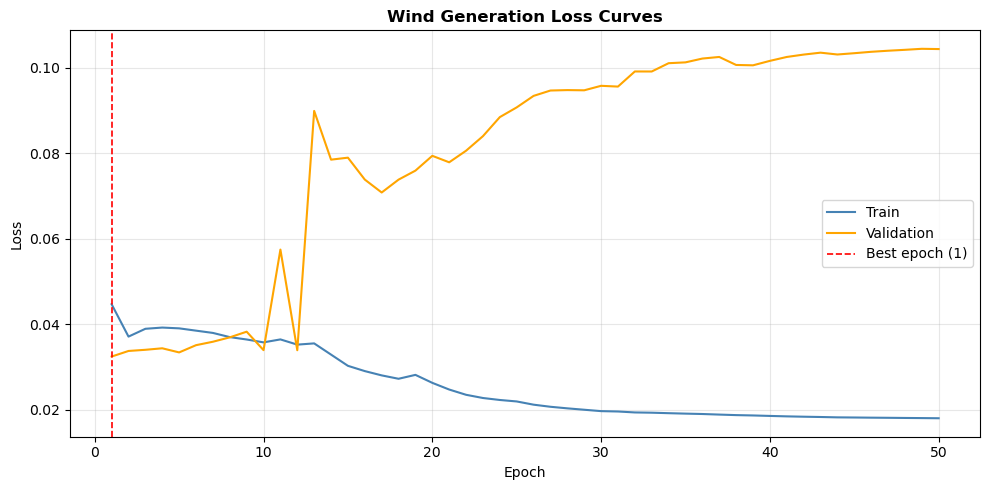


STAGE 2 — total load actual  (X width=58)
Total Load Forecast Day Ahead Model params: 4156610
Loss: MSE


  ✅ Epoch   1 — best model saved val=0.0502
Epoch   1/50 | Train: 0.0608 | Val: 0.0502 | LR: 0.001000 | Time: 0m 05s


  ✅ Epoch   2 — best model saved val=0.0422
Epoch   2/50 | Train: 0.0470 | Val: 0.0422 | LR: 0.001000 | Time: 0m 05s


Epoch   3/50 | Train: 0.0446 | Val: 0.0424 | LR: 0.001000 | Time: 0m 04s


Epoch   4/50 | Train: 0.0441 | Val: 0.0427 | LR: 0.001000 | Time: 0m 04s


...

Epoch  25/50 | Train: 0.0138 | Val: 0.0333 | LR: 0.000250 | Time: 0m 04s


Epoch  26/50 | Train: 0.0134 | Val: 0.0367 | LR: 0.000250 | Time: 0m 04s


Epoch  27/50 | Train: 0.0130 | Val: 0.0393 | LR: 0.000125 | Time: 0m 05s


Epoch  28/50 | Train: 0.0130 | Val: 0.0379 | LR: 0.000125 | Time: 0m 04s


Epoch  29/50 [Train]:  66%|██████▌   | 44/67 [00:02<00:01, 14.99it/s, avg=0.0138]

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Single Configuration Pipeline
# Trains all four stages in sequence, evaluates on val set after each stage,
# and runs final test evaluation once all stages are complete.
# ══════════════════════════════════════════════════════════════════════════════

# ── Configuration ─────────────────────────────────────────────────────────────
cfg = {'arch'               : 'cnnlstm',
       'hidden_size'        : 256,                  # CNN+LSTM
       'cnn_channels'       : (64, 128, 256),       # CNN+LSTM
       'kernel_sizes'       : (3, 8, 12),            # CNN+LSTM
       'd_model'            : 64,                  # Transformer (note: must be divisible by nhead, similar to hidden_size in LSTM)
       'nhead'              : 4,                    # Transformer
       'num_enc_layers'     : 2,                    # Transformer
       'dim_feedforward'    : 256,                  # Transformer (width of 2-layer feedforward network inside each transformer encoder layer; typically 2 or 4 x d_model)
       'dropout'            : 0.1,                  
       'lr'                 : 1e-3, 
       'loss_fn'            : 'mse'}

NUM_EPOCHS = 50
FOLD_IDX   = 0
fold_data  = folds[FOLD_IDX]
fn         = fold_data['fold']

print(f"Fold {fn}: train={fold_data['train_years']}  "
      f"val={fold_data['val_years']}  test={fold_data['test_years']} (held out)")
print(f"Config: {cfg}\n")

# ── Reset cascade to base feature arrays ──────────────────────────────────────
reset_cascade(fold_data)

# Create different dataloader for weather dependent predictions (gen_solar, gen_wind)
GEN_COLS = ['gen_hydro', 'gen_pumped_hydro', 'gen_fossil', 'gen_nuclear', 'gen_other']

# Obtain the column indices for all other generation columns
gen_idx = [i for i, col in enumerate(BASE_HIST_FEAT_COLS) if col in GEN_COLS]

for split in ('train', 'val', 'test'):
    fold_data[f'X_nogen_{split}'] = np.delete(
        fold_data[f'X_{split}'], gen_idx, axis=1)
    # X_{split}_full already exists as fold_data[f'X_{split}']

# Storage for trained models, histories, and val metrics
trained_models  = {}
histories       = {}
val_metrics     = {}
test_loaders    = {}

# Create generation and load dataloaders using historical data (no appending)
tr_gs, va_gs, te_gs = create_dataloader_DA(fold_data, 'gen_solar', x_key='X_nogen')               # Exclude other generation data from prediction
tr_gw, va_gw, te_gw = create_dataloader_DA(fold_data, 'gen_wind', x_key='X_nogen')                # Exclude other generation data from prediction
tr_load, va_load, te_load = create_dataloader_DA(fold_data, 'total load actual', x_key='X_nogen') # Exclude other generation data from prediction

# Define a function to count model parameters
def param_count(m): 
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1a — gen_solar
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"STAGE 1a — gen_solar  (X width={fold_data['X_nogen_train'].shape[1]})")
print(f"{'='*60}")

# Instantiate the model
model_gs = build_dayahead_model(fold_data['X_nogen_train'].shape[1], cfg)

print(f'Solar Generation Forecast Day Ahead Model params: {param_count(model_gs)}')

# Train the model
model_gs, hist_gs = train_model(
    model_gs, tr_gs, va_gs,
    model_type='dayahead',
    num_epochs=NUM_EPOCHS,
    lr=cfg['lr'],
    loss_fn=cfg['loss_fn']
)

# Evaluate the model on the validation set
preds_gs, acts_gs, metrics_gs = evaluate_model(
    model_gs, va_gs,
    fold_data['target_scalers']['gen_solar'],
    model_type='dayahead',
    split_name='val'
)

# Store histories and metrics
trained_models['gen_solar'] = model_gs
histories['gen_solar']      = hist_gs
val_metrics['gen_solar']    = metrics_gs
test_loaders['gen_solar']   = te_gs

# Plot training and validation loss curves
plot_loss_curves(hist_gs, title='Solar Generation Loss Curves')

# ══════════════════════════════════════════════════════════════════════════════
# STAGE 1b — gen_wind
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"STAGE 1b — gen_wind  (X width={fold_data['X_nogen_train'].shape[1]})")
print(f"{'='*60}")

# Instantiate the model
model_gw = build_dayahead_model(fold_data['X_nogen_train'].shape[1], cfg)

print(f'Wind Generation Forecast Day Ahead Model params: {param_count(model_gw)}')

# # Instantiate the model
# model_gw = DayAheadModel(
#     input_size=fold_data['X_train'].shape[1],
#     hidden_size=cfg['hidden_size'],
#     num_layers=NUM_LAYERS,
#     dropout=cfg['dropout']
# )

# Train the model
model_gw, hist_gw = train_model(
    model_gw, tr_gw, va_gw,
    model_type='dayahead',
    num_epochs=NUM_EPOCHS,
    lr=cfg['lr'],
    loss_fn=cfg['loss_fn']
)

# Evaluate the model
preds_gw, acts_gw, metrics_gw = evaluate_model(
    model_gw, va_gw,
    fold_data['target_scalers']['gen_wind'],
    model_type='dayahead',
    split_name='val'
)

# Store histories and metrics
trained_models['gen_wind']  = model_gw
histories['gen_wind']       = hist_gw
val_metrics['gen_wind']     = metrics_gw
test_loaders['gen_wind']    = te_gw

# Plot training and validation loss curves
plot_loss_curves(hist_gw, title='Wind Generation Loss Curves')

# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — total load actual
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"STAGE 2 — total load actual  (X width={fold_data['X_nogen_train'].shape[1]})")
print(f"{'='*60}")

# Instantiate the model
model_load = build_dayahead_model(fold_data['X_nogen_train'].shape[1], cfg)

print(f'Total Load Forecast Day Ahead Model params: {param_count(model_load)}')

# # Instantiate the model
# model_load = DayAheadModel(
#     input_size=fold_data['X_train'].shape[1],
#     hidden_size=cfg['hidden_size'],
#     num_layers=NUM_LAYERS,
#     dropout=cfg['dropout']
# )

# Train the model
model_load, hist_load = train_model(
    model_load, tr_load, va_load,
    model_type='dayahead',
    num_epochs=NUM_EPOCHS,
    lr=cfg['lr'],
    loss_fn=cfg['loss_fn']
)

# Evaluate the model
preds_load, acts_load, metrics_load = evaluate_model(
    model_load, va_load,
    fold_data['target_scalers']['total load actual'],
    model_type='dayahead',
    split_name='val'
)

# Store the histories and metrics
trained_models['total load actual'] = model_load
histories['total load actual']      = hist_load
val_metrics['total load actual']    = metrics_load
test_loaders['total load actual']   = te_load

# Plot training and validation loss curves
plot_loss_curves(hist_load, title='Total Load Loss Curves')

# ══════════════════════════════════════════════════════════════════════════════
# Append forecasts for generation and load to X for predicting prices
# ══════════════════════════════════════════════════════════════════════════════

# Get the predictions from the generation and load models
preds_solar = get_cascade_preds(fold_data, 'gen_solar',           model_gs, x_key='X_nogen')
preds_wind  = get_cascade_preds(fold_data, 'gen_wind',            model_gw, x_key='X_nogen')
preds_load  = get_cascade_preds(fold_data, 'total load actual',   model_load, x_key='X_nogen')

# ── 2. Append all predictions at once ───────────────────────────────────────
print(f"\nAppending parallel cascade predictions...")
for split in ('train', 'val', 'test'):
    new_cols = np.column_stack([
        preds_solar[split],
        preds_wind[split],
        preds_load[split],
    ])
    fold_data[f'X_{split}'] = np.hstack([fold_data[f'X_{split}'], new_cols])

print(f"X width after appending: {fold_data['X_train'].shape[1]}")

# print(f"\nAppending parallel cascade predictions...")
# append_cascade_to_fold(fold_data, 'gen_solar', model_gs)
# append_cascade_to_fold(fold_data, 'gen_wind', model_gw)
# append_cascade_to_fold(fold_data, 'total load actual', model_load)
# print(f"X width after appending: {fold_data['X_train'].shape[1]}")

# ══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — price day ahead
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"STAGE 3 — price day ahead  (X width={fold_data['X_train'].shape[1]})")
print(f"{'='*60}")

# Create the data split
tr_pda, va_pda, te_pda = create_dataloader_DA(fold_data, PRICE_DA_TARGET)

# Instantiate the model
model_pda = build_dayahead_model(fold_data['X_train'].shape[1], cfg)

print(f'Price Day Ahead Model params: {param_count(model_pda)}')

# # Instantiate the model
# model_pda = DayAheadModel(
#     input_size=fold_data['X_train'].shape[1],
#     hidden_size=cfg['hidden_size'],
#     num_layers=NUM_LAYERS,
#     dropout=cfg['dropout']
# )

# Train the model
model_pda, hist_pda = train_model(
    model_pda, tr_pda, va_pda,
    model_type='dayahead',
    num_epochs=NUM_EPOCHS,
    lr=cfg['lr'],
    loss_fn=cfg['loss_fn']
)

# Evaluate the model
preds_pda, acts_pda, metrics_pda = evaluate_model(
    model_pda, va_pda,
    fold_data['target_scalers'][PRICE_DA_TARGET],
    model_type='dayahead',
    split_name='val'
)

# Plot training and validation loss curves
plot_loss_curves(hist_pda, title='Day Ahead Price Loss Curves')

# Store the histories and metrics
trained_models[PRICE_DA_TARGET] = model_pda
histories[PRICE_DA_TARGET]      = hist_pda
val_metrics[PRICE_DA_TARGET]    = metrics_pda
test_loaders[PRICE_DA_TARGET]   = te_pda

# ══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — price actual (real-time) - note: actual day ahead price added for prediction, NOT predicted day ahead price
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"STAGE 4 — price actual RT  "
      f"(X width={fold_data['X_train'].shape[1]}, "
      f"Stream 2 width={INPUT_SIZE_FC})")
print(f"{'='*60}")

# Create the data split
tr_rt, va_rt, te_rt = create_dataloader_RT(fold_data, PRICE_RT_TARGET)

# Instantiate the model
model_prt = build_realtime_model(fold_data['X_train'].shape[1], INPUT_SIZE_FC, cfg)

print(f'Price Real Time Model params: {param_count(model_prt)}')

# # Instantiate the model
# model_prt = RealTimeModel(
#     input_size=fold_data['X_train'].shape[1],
#     n_forecast_features=INPUT_SIZE_FC,
#     hidden_size=cfg['hidden_size'],
#     num_layers=NUM_LAYERS,
#     dropout=cfg['dropout']
# )

# Train the model
model_prt, hist_prt = train_model(
    model_prt, tr_rt, va_rt,
    model_type='realtime',
    num_epochs=NUM_EPOCHS,
    lr=cfg['lr'],
    loss_fn=cfg['loss_fn']
)

# Evaluate the model
preds_prt, acts_prt, metrics_prt = evaluate_model(
    model_prt, va_rt,
    fold_data['target_scalers'][PRICE_RT_TARGET],
    model_type='realtime',
    split_name='val'
)

# Plot training and validation loss curves
plot_loss_curves(hist_prt, title='Real Time Price Loss Curves')

# Store the histories and metrics
trained_models[PRICE_RT_TARGET] = model_prt
histories[PRICE_RT_TARGET]      = hist_prt
val_metrics[PRICE_RT_TARGET]    = metrics_prt
test_loaders[PRICE_RT_TARGET]   = te_rt

# ══════════════════════════════════════════════════════════════════════════════
# VALIDATION SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"VALIDATION SUMMARY")
print(f"{'='*65}")
print(f"{'Stage':<38} {'MAE':>8} {'RMSE':>8} {'MAE%':>7}  Status")
print(f"{'-'*65}")

STAGE_ORDER = [
    ('gen_solar',         'Stage 1a — gen_solar',        'dayahead'),
    ('gen_wind',          'Stage 1b — gen_wind',          'dayahead'),
    ('total load actual', 'Stage 2  — total load actual', 'dayahead'),
    (PRICE_DA_TARGET,     'Stage 3  — price day ahead',   'dayahead'),
    (PRICE_RT_TARGET,     'Stage 4  — price actual (RT)', 'realtime'),
]

for target, stage_label, _ in STAGE_ORDER:
    m = val_metrics[target]
    s = '✅' if m['mape'] < 10 else ('⚠️' if m['mape'] < 20 else '❌')
    print(f"{stage_label:<38} {m['mae']:>8.3f}  {m['rmse']:>8.3f}  "
          f"{m['mape']:>6.2f}%  {s}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL TEST EVALUATION
# Run once only — do not adjust anything after seeing these numbers
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print(f"FINAL TEST EVALUATION")
print(f"{'='*65}")

test_results = {}

for target, stage_label, mtype in STAGE_ORDER:
    print(f"\n── {stage_label} ──")
    model = trained_models[target]

    if mtype == 'realtime':
        _, _, te_rt = create_dataloader_RT(fold_data)
        preds, acts, metrics = evaluate_model(
            model,
            test_loaders[target],       # Use stored loader, not rebuilt
            fold_data['target_scalers'][target],
            model_type='realtime',
            split_name='test'
        )
    else:
        _, _, te = create_dataloader_DA(fold_data, target)
        preds, acts, metrics = evaluate_model(
            model,
            test_loaders[target],       # Use stored loader, not rebuilt
            fold_data['target_scalers'][target],
            model_type='dayahead',
            split_name='test'
        )
    test_results[target] = {'preds': preds, 'actuals': acts, 'metrics': metrics}

print(f"\n{'='*65}")
print(f"TEST SUMMARY  —  Config: {cfg}")
print(f"{'='*65}")
print(f"{'Stage':<38} {'MAE':>8} {'RMSE':>8} {'MAE%':>7}  Status")
print(f"{'-'*65}")

for target, stage_label, _ in STAGE_ORDER:
    m = test_results[target]['metrics']
    s = '✅' if m['mape'] < 10 else ('⚠️' if m['mape'] < 20 else '❌')
    print(f"{stage_label:<38} {m['mae']:>8.3f}  {m['rmse']:>8.3f}  "
          f"{m['mape']:>6.1f}%  {s}")

In [ ]:
# Save the predictions, actuals, metrics for test set

# Create directory for storing results
os.makedirs('test_results_cnnlstm-v3', exist_ok=True)

# Save results for each target on the test set
for target, stage_label, _ in STAGE_ORDER:
    r = test_results[target]
    safe_name = target.replace(' ', '_')

    # Save predictions and actuals as numpy arrays
    np.save(f'test_results/{safe_name}_preds.npy', r['preds'])
    np.save(f'test_results/{safe_name}_actuals.npy', r['actuals'])

    # Save metrics as JSON
    with open(f'results/{safe_name}_metrics.json', 'w') as f:
        json.dump(r['metrics'], f, indent=2)

    print(f"Saved: results/{safe_name}_preds.npy  |  "
          f"results/{safe_name}_actuals.npy  |  "
          f"results/{safe_name}_metrics.json")

## OLD CODE

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# import numpy as np

# def evaluate_results(all_results, all_history,
#                      target_cols, target_ranges):

#     # ── 1. Metrics table ─────────────────────────────────
#     print(f"\n{'='*75}")
#     print(f"TEST RESULTS — FOLD 5")
#     print(f"{'='*75}")
#     print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
#           f"{'24hr MAE':>10} {'24hr RMSE':>11} "
#           f"{'MAE%':>7} {'Status'}")
#     print("-" * 85)

#     for target in target_cols:
#         m       = all_results[target]['metrics']
#         r       = m['test_range']
#         mae_pct = m['1hr']['mae_pct']

#         status  = '✅ Good' if mae_pct < 10 else \
#                   '⚠️  OK'  if mae_pct < 20 else \
#                   '❌ High'

#         print(f"{target:<30} "
#               f"{r['range']:>12.2f} "
#               f"{m['1hr']['mae']:>9.2f} "
#               f"{m['1hr']['rmse']:>10.2f} "
#               f"{m['24hr']['mae']:>10.2f} "
#               f"{m['24hr']['rmse']:>11.2f} "
#               f"{mae_pct:>8.1f}% "
#               f"  {status}")

#     # ── 2. Plots per target ───────────────────────────────
#     for target in target_cols:

#         preds_1hr    = all_results[target]['preds_1hr']
#         preds_24hr   = all_results[target]['preds_24hr']
#         actuals_1hr  = all_results[target]['actuals_1hr']
#         actuals_24hr = all_results[target]['actuals_24hr']
#         metrics      = all_results[target]['metrics']
#         history      = all_history[target]

#         fig = plt.figure(figsize=(16, 20))
#         fig.suptitle(f'{target}', 
#                      fontsize=14, fontweight='bold', y=1.01)

#         gs = gridspec.GridSpec(4, 2, figure=fig,
#                                hspace=0.5, wspace=0.3)

#         # ── Plot 1: Full test period 1hr ─────────────
#         ax1 = fig.add_subplot(gs[0, :])
#         ax1.plot(actuals_1hr.flatten(),
#                  label='Actual',
#                  alpha=0.7, color='steelblue', linewidth=0.8)
#         ax1.plot(preds_1hr.flatten(),
#                  label='Predicted',
#                  alpha=0.7, color='orange', linewidth=0.8)
#         ax1.set_title(
#             f'1hr Ahead — Full Test Period\n'
#             f'MAE={metrics["1hr"]["mae"]:.2f}  '
#             f'RMSE={metrics["1hr"]["rmse"]:.2f}')
#         ax1.set_xlabel('Hour')
#         ax1.set_ylabel('Value')
#         ax1.legend()
#         ax1.grid(True, alpha=0.3)

#         # ── Plot 2: Zoomed 7 days 1hr ─────────────────
#         ax2 = fig.add_subplot(gs[1, 0])
#         ax2.plot(actuals_1hr[:168].flatten(),
#                  label='Actual',
#                  alpha=0.7, color='steelblue')
#         ax2.plot(preds_1hr[:168].flatten(),
#                  label='Predicted',
#                  alpha=0.7, color='orange')
#         ax2.set_title('1hr Ahead — First 7 Days')
#         ax2.set_xlabel('Hour')
#         ax2.set_ylabel('Value')
#         ax2.legend()
#         ax2.grid(True, alpha=0.3)

#         # ── Plot 3: Residuals 1hr ─────────────────────
#         ax3 = fig.add_subplot(gs[1, 1])
#         residuals_1hr = actuals_1hr.flatten() - \
#                         preds_1hr.flatten()
#         ax3.plot(residuals_1hr[:168],
#                  color='red', alpha=0.6, linewidth=0.8)
#         ax3.axhline(y=0, color='black',
#                     linestyle='--', linewidth=1)
#         ax3.set_title(
#             f'1hr Residuals — First 7 Days\n'
#             f'Mean={residuals_1hr.mean():.2f}  '
#             f'Std={residuals_1hr.std():.2f}')
#         ax3.set_xlabel('Hour')
#         ax3.set_ylabel('Residual')
#         ax3.grid(True, alpha=0.3)

#         # ── Plot 4: 24hr ahead — one sample ──────────
#         ax4 = fig.add_subplot(gs[2, 0])
#         sample_idx = 0   # first sample
#         ax4.plot(range(24),
#                  actuals_24hr[sample_idx],
#                  label='Actual',
#                  alpha=0.7, color='steelblue',
#                  marker='o', markersize=4)
#         ax4.plot(range(24),
#                  preds_24hr[sample_idx],
#                  label='Predicted',
#                  alpha=0.7, color='orange',
#                  marker='x', markersize=4)
#         ax4.set_title(
#             f'24hr Ahead — Sample Day 1\n'
#             f'MAE={metrics["24hr"]["mae"]:.2f}  '
#             f'RMSE={metrics["24hr"]["rmse"]:.2f}')
#         ax4.set_xlabel('Hour of Day')
#         ax4.set_ylabel('Value')
#         ax4.legend()
#         ax4.grid(True, alpha=0.3)

#         # ── Plot 5: 24hr ahead — another sample ──────
#         ax5 = fig.add_subplot(gs[2, 1])
#         sample_idx = 100  # different day
#         ax5.plot(range(24),
#                  actuals_24hr[sample_idx],
#                  label='Actual',
#                  alpha=0.7, color='steelblue',
#                  marker='o', markersize=4)
#         ax5.plot(range(24),
#                  preds_24hr[sample_idx],
#                  label='Predicted',
#                  alpha=0.7, color='orange',
#                  marker='x', markersize=4)
#         ax5.set_title(f'24hr Ahead — Sample Day 100')
#         ax5.set_xlabel('Hour of Day')
#         ax5.set_ylabel('Value')
#         ax5.legend()
#         ax5.grid(True, alpha=0.3)

#         # ── Plot 6: Scatter plot actual vs predicted ──
#         ax6 = fig.add_subplot(gs[3, 0])
#         ax6.scatter(actuals_1hr.flatten(),
#                     preds_1hr.flatten(),
#                     alpha=0.2, color='steelblue',
#                     s=5)
#         # perfect prediction line
#         min_val = min(actuals_1hr.min(), preds_1hr.min())
#         max_val = max(actuals_1hr.max(), preds_1hr.max())
#         ax6.plot([min_val, max_val],
#                  [min_val, max_val],
#                  'r--', linewidth=1.5,
#                  label='Perfect prediction')
#         ax6.set_title('Actual vs Predicted (1hr)')
#         ax6.set_xlabel('Actual')
#         ax6.set_ylabel('Predicted')
#         ax6.legend()
#         ax6.grid(True, alpha=0.3)

#         # ── Plot 7: Loss curves ───────────────────────
#         ax7 = fig.add_subplot(gs[3, 1])
#         epochs = range(1, len(history['train_loss']) + 1)
#         ax7.plot(epochs, history['train_loss'],
#                  label='Train Loss',
#                  color='steelblue', linewidth=1.5)
#         ax7.plot(epochs, history['val_loss'],
#                  label='Val Loss',
#                  color='orange', linewidth=1.5)
#         ax7.set_title(f'Loss Curve')
#         ax7.set_xlabel('Epoch')
#         ax7.set_ylabel('Loss')
#         ax7.legend()
#         ax7.grid(True, alpha=0.3)

#         plt.tight_layout()
#         plt.show()


# # ── Run evaluation ────────────────────────────────────────
# # target_ranges = {
# #     'generation solar'       : 5783.00,
# #     'generation wind onshore': 17202.00,
# #     'total load actual'      : 22974.00,
# #     'price actual'           : 107.47,
# #     'price day ahead'        : 99.69
# # }

# evaluate_results(
#     all_results,
#     all_history,
#     target_cols
# )

In [ ]:
# def plot_all_targets(all_results, all_history,
#                      target_cols):

#     # ── 1. Summary metrics table ──────────────────────────
#     print(f"\n{'='*85}")
#     print(f"TEST RESULTS SUMMARY — ALL TARGETS — FOLD 5")
#     print(f"{'='*85}")
#     print(f"\n{'Target':<30} {'1hr MAE':>9} {'1hr RMSE':>10} "
#           f"{'24hr MAE':>10} {'24hr RMSE':>11} "
#           f"{'MAE%':>7} {'Status'}")
#     print("-" * 85)

#     for target in target_cols:
#         m       = all_results[target]['metrics']
#         r       = m['test_range']
#         mae_pct = m['1hr']['mae_pct']
#         status  = '✅ Good' if mae_pct < 10 else \
#                   '⚠️  OK'  if mae_pct < 20 else \
#                   '❌ High'
#         print(f"{target:<30} "
#               f"{r['range']:>12.2f} "
#               f"{m['1hr']['mae']:>9.2f} "
#               f"{m['1hr']['rmse']:>10.2f} "
#               f"{m['24hr']['mae']:>10.2f} "
#               f"{m['24hr']['rmse']:>11.2f} "
#               f"{mae_pct:>6.1f}% "
#               f"  {status}")

#     # ── 2. All targets — 1hr actual vs predicted ──────────
#     fig, axes = plt.subplots(
#         len(target_cols), 1,
#         figsize=(16, 5 * len(target_cols))
#     )
#     fig.suptitle('1hr Ahead — Actual vs Predicted — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         preds   = all_results[target]['preds_1hr'].flatten()
#         actuals = all_results[target]['actuals_1hr'].flatten()
#         m       = all_results[target]['metrics']['1hr']

#         axes[i].plot(actuals,
#                      label='Actual',
#                      color='steelblue',
#                      alpha=0.7, linewidth=0.8)
#         axes[i].plot(preds,
#                      label='Predicted',
#                      color='orange',
#                      alpha=0.7, linewidth=0.8)
#         axes[i].set_title(
#             f'{target}  |  '
#             f'MAE={m["mae"]:.2f}  RMSE={m["rmse"]:.2f}')
#         axes[i].set_xlabel('Hour')
#         axes[i].set_ylabel('Value')
#         axes[i].legend(loc='upper right')
#         axes[i].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # ── 3. All targets — zoomed 7 days ────────────────────
#     fig, axes = plt.subplots(
#         len(target_cols), 1,
#         figsize=(16, 5 * len(target_cols))
#     )
#     fig.suptitle('1hr Ahead — First 7 Days — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         preds   = all_results[target]['preds_1hr'].flatten()
#         actuals = all_results[target]['actuals_1hr'].flatten()

#         axes[i].plot(actuals[:168],
#                      label='Actual',
#                      color='steelblue',
#                      alpha=0.7, linewidth=1.2)
#         axes[i].plot(preds[:168],
#                      label='Predicted',
#                      color='orange',
#                      alpha=0.7, linewidth=1.2)
#         axes[i].set_title(f'{target} — First 7 Days')
#         axes[i].set_xlabel('Hour')
#         axes[i].set_ylabel('Value')
#         axes[i].legend(loc='upper right')
#         axes[i].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # ── 4. All targets — 24hr ahead sample day ────────────
#     fig, axes = plt.subplots(
#         len(target_cols), 2,
#         figsize=(16, 5 * len(target_cols))
#     )
#     fig.suptitle('24hr Ahead — Sample Days — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         preds_24hr   = all_results[target]['preds_24hr']
#         actuals_24hr = all_results[target]['actuals_24hr']
#         m            = all_results[target]['metrics']['24hr']

#         for j, sample_idx in enumerate([0, 100]):
#             axes[i, j].plot(
#                 range(24),
#                 actuals_24hr[sample_idx],
#                 label='Actual',
#                 color='steelblue',
#                 alpha=0.7,
#                 marker='o', markersize=4)
#             axes[i, j].plot(
#                 range(24),
#                 preds_24hr[sample_idx],
#                 label='Predicted',
#                 color='orange',
#                 alpha=0.7,
#                 marker='x', markersize=4)
#             axes[i, j].set_title(
#                 f'{target}\n'
#                 f'24hr Sample Day {sample_idx+1}  |  '
#                 f'MAE={m["mae"]:.2f}')
#             axes[i, j].set_xlabel('Hour of Day')
#             axes[i, j].set_ylabel('Value')
#             axes[i, j].legend(loc='upper right')
#             axes[i, j].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # ── 5. All targets — scatter actual vs predicted ──────
#     fig, axes = plt.subplots(
#         1, len(target_cols),
#         figsize=(5 * len(target_cols), 5)
#     )
#     fig.suptitle('Actual vs Predicted Scatter — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         preds   = all_results[target]['preds_1hr'].flatten()
#         actuals = all_results[target]['actuals_1hr'].flatten()

#         axes[i].scatter(actuals, preds,
#                         alpha=0.2, color='steelblue', s=3)

#         # perfect prediction line
#         min_val = min(actuals.min(), preds.min())
#         max_val = max(actuals.max(), preds.max())
#         axes[i].plot([min_val, max_val],
#                      [min_val, max_val],
#                      'r--', linewidth=1.5,
#                      label='Perfect')
#         axes[i].set_title(f'{target.split(" ")[-1]}')
#         axes[i].set_xlabel('Actual')
#         axes[i].set_ylabel('Predicted')
#         axes[i].legend()
#         axes[i].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # ── 6. All targets — residuals ────────────────────────
#     fig, axes = plt.subplots(
#         len(target_cols), 1,
#         figsize=(16, 4 * len(target_cols))
#     )
#     fig.suptitle('Residuals — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         preds   = all_results[target]['preds_1hr'].flatten()
#         actuals = all_results[target]['actuals_1hr'].flatten()
#         res     = actuals - preds

#         axes[i].plot(res[:168],
#                      color='red', alpha=0.6,
#                      linewidth=0.8)
#         axes[i].axhline(y=0, color='black',
#                         linestyle='--', linewidth=1)
#         axes[i].fill_between(range(168),
#                               res[:168], 0,
#                               alpha=0.2, color='red')
#         axes[i].set_title(
#             f'{target}  |  '
#             f'Mean={res.mean():.2f}  '
#             f'Std={res.std():.2f}')
#         axes[i].set_xlabel('Hour')
#         axes[i].set_ylabel('Residual')
#         axes[i].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     # ── 7. All targets — loss curves ──────────────────────
#     fig, axes = plt.subplots(
#         len(target_cols), 1,
#         figsize=(12, 4 * len(target_cols))
#     )
#     fig.suptitle('Training & Validation Loss — All Targets',
#                  fontsize=14, fontweight='bold')

#     for i, target in enumerate(target_cols):
#         history = all_history[target]
#         epochs  = range(1, len(history['train_loss']) + 1)

#         axes[i].plot(epochs, history['train_loss'],
#                      label='Train Loss',
#                      color='steelblue', linewidth=1.5)
#         axes[i].plot(epochs, history['val_loss'],
#                      label='Val Loss',
#                      color='orange', linewidth=1.5)
#         axes[i].set_title(f'Loss Curve — {target}')
#         axes[i].set_xlabel('Epoch')
#         axes[i].set_ylabel('Loss')
#         axes[i].legend()
#         axes[i].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()


# # ── Run ───────────────────────────────────────────────────
# # target_ranges = {
# #     'generation solar'       : 5783.00,
# #     'generation wind onshore': 17202.00,
# #     'total load actual'      : 22974.00,
# #     'price actual'           : 107.47,
# #     'price day ahead'        : 99.69
# # }

# plot_all_targets(
#     all_results,
#     all_history,
#     target_cols,
# )